# Empirical CAPM Testing on the Russian Stock Market (2018–2024)

## Методология
1. **Time-Series OLS** (Sharpe, 1964; Lintner, 1965): для каждой акции оцениваем α и β
2. **Fama-MacBeth Two-Pass** (1973): проверяем, оценивает ли рынок бета-риск
3. **GRS Test** (Gibbons, Ross, Shanken, 1989): совместная значимость всех альф

**CAPM предсказывает:**
- $\alpha_i = 0$ для всех активов
- $\gamma_0 = 0$ (нулевая бета = безрисковая ставка)
- $\gamma_1 = E[R_m - r_f]$ (бета полностью объясняет кросс-секцию)

**Данные:** Yahoo Finance (.ME), ОФЗ 1Y как $r_f$, рыночный индекс IMOEX.ME

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. ИМПОРТЫ И НАСТРОЙКИ
# ─────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
})

print('Все библиотеки загружены.')

Все библиотеки загружены.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. КОНФИГУРАЦИЯ
# ─────────────────────────────────────────────────────────────────────────────
START = '2018-01-01'
END   = '2024-12-31'

# Топ-30 ликвидных бумаг ММВБ (суффикс .ME = Московская биржа на Yahoo Finance)
TICKERS = [
    'SBER.ME',   # Сбербанк
    'GAZP.ME',   # Газпром
    'LKOH.ME',   # Лукойл
    'NVTK.ME',   # Новатэк
    'ROSN.ME',   # Роснефть
    'GMKN.ME',   # Норникель
    'TATN.ME',   # Татнефть
    'CHMF.ME',   # Северсталь
    'NLMK.ME',   # НЛМК
    'ALRS.ME',   # Алроса
    'MTSS.ME',   # МТС
    'VTBR.ME',   # ВТБ
    'PIKK.ME',   # ПИК
    'AFLT.ME',   # Аэрофлот
    'RUAL.ME',   # Русал
    'MOEX.ME',   # Московская биржа
    'PLZL.ME',   # Полюс Золото
    'HYDR.ME',   # РусГидро
    'IRAO.ME',   # Интер РАО
    'MAGN.ME',   # ММК
    'SNGS.ME',   # Сургутнефтегаз
    'PHOR.ME',   # ФосАгро
    'MGNT.ME',   # Магнит
    'SBERP.ME',  # Сбербанк преф.
    'TRNFP.ME',  # Транснефть преф.
    'FEES.ME',   # ФСК ЕЭС
    'YNDX.ME',   # Яндекс (торговался до реструктуризации)
    'TCSG.ME',   # TCS Group (Тинькофф)
    'POSI.ME',   # Positive Technologies
    'OZON.ME',   # Ozon
]

MARKET_TICKER = 'IMOEX.ME'   # Индекс Московской биржи
MIN_OBS_FRAC  = 0.60         # Минимум 60% наблюдений для включения акции

print(f'Акций в выборке: {len(TICKERS)}')
print(f'Период: {START} — {END}')

Акций в выборке: 30
Период: 2018-01-01 — 2024-12-31


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. БЕЗРИСКОВАЯ СТАВКА — ОФЗ 1Y (средняя доходность за год)
# ─────────────────────────────────────────────────────────────────────────────
# Источник: данные ЦБ РФ / Московской биржи (средняя доходность ОФЗ ~1 год)
# https://www.cbr.ru/hd_base/zcyc_params/zcyc/
OFZ_ANNUAL = {
    2018: 0.0730,   # средняя ~7.30%
    2019: 0.0680,   # снижение ключевой ставки
    2020: 0.0520,   # COVID: снижение до 4.25%
    2021: 0.0625,   # начало цикла повышения
    2022: 0.1050,   # санкции: скачок до 20%, затем снижение
    2023: 0.0975,   # ~10% среднегодовая
    2024: 0.1520,   # повышение до 21%
}

# Непрерывно начисляемая месячная ставка: r_monthly = ln(1 + r_annual) / 12
def annual_to_monthly_log(r_annual: float) -> float:
    return np.log(1 + r_annual) / 12

# Строим месячный ряд (начало каждого месяца)
date_range = pd.date_range(start=START, end=END, freq='MS')
rf_series  = pd.Series(
    {d: annual_to_monthly_log(OFZ_ANNUAL[d.year]) for d in date_range},
    name='rf'
)
rf_series.index = pd.PeriodIndex(rf_series.index, freq='M')

print('Безрисковая ставка ОФЗ (месячная, логарифмическая):')
rf_annual_check = rf_series.groupby(rf_series.index.year).mean() * 12 * 100
rf_annual_check.name = 'rf % (annualized)'
print(rf_annual_check.apply(lambda x: f'{x:.2f}%').to_string())

Безрисковая ставка ОФЗ (месячная, логарифмическая):
2018     7.05%
2019     6.58%
2020     5.07%
2021     6.06%
2022     9.98%
2023     9.30%
2024    14.15%


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. ЗАГРУЗКА ДАННЫХ С YAHOO FINANCE
# ─────────────────────────────────────────────────────────────────────────────
all_tickers = TICKERS + [MARKET_TICKER]

print('Загружаем котировки (monthly, adjusted)...')
raw = yf.download(
    all_tickers,
    start=START,
    end=END,
    interval='1mo',
    auto_adjust=True,
    progress=True,
    group_by='ticker',
)

# Извлекаем цены закрытия
if isinstance(raw.columns, pd.MultiIndex):
    close = raw.xs('Close', axis=1, level=1)
else:
    close = raw[['Close']]

# Приводим индекс к PeriodIndex(M) для совместимости с rf
close.index = pd.PeriodIndex(close.index, freq='M')

print(f'\nЗагружено: {close.shape[0]} месяцев × {close.shape[1]} инструментов')
print(f'Период: {close.index[0]} — {close.index[-1]}')

# Доля пропущенных значений
miss = close.isnull().mean().sort_values(ascending=False)
print('\nДоля пропусков по инструментам:')
print(miss[miss > 0].apply(lambda x: f'{x*100:.1f}%').to_string())

Загружаем котировки (monthly, adjusted)...


[                       0%                       ]

[***                    6%                       ]  2 of 31 completed

[***                    6%                       ]  2 of 31 completed

[********              16%                       ]  5 of 31 completed

...

[*********************100%***********************]  31 of 31 completed



3 Failed downloads:


['POSI.ME']: possibly delisted; no price data found  (1mo 2018-01-01 -> 2024-12-31)


['OZON.ME', 'YNDX.ME']: possibly delisted; no timezone found



Загружено: 55 месяцев × 31 инструментов
Период: 2018-01 — 2022-07

Доля пропусков по инструментам:
Ticker
YNDX.ME     100.0%
OZON.ME     100.0%
POSI.ME     100.0%
TCSG.ME      41.8%
PLZL.ME       3.6%
MAGN.ME       3.6%
NVTK.ME       3.6%
TRNFP.ME      3.6%
NLMK.ME       3.6%
SBERP.ME      3.6%
LKOH.ME       3.6%
RUAL.ME       3.6%
VTBR.ME       3.6%
MOEX.ME       3.6%
TATN.ME       3.6%
MGNT.ME       3.6%
HYDR.ME       3.6%
SNGS.ME       3.6%
PIKK.ME       3.6%
GAZP.ME       3.6%
ALRS.ME       3.6%
GMKN.ME       3.6%
IRAO.ME       3.6%
CHMF.ME       3.6%
AFLT.ME       3.6%
PHOR.ME       3.6%
MTSS.ME       3.6%
SBER.ME       3.6%
ROSN.ME       3.6%
FEES.ME       3.6%


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. ОЧИСТКА, ДОХОДНОСТИ, ФИЛЬТРАЦИЯ
# ─────────────────────────────────────────────────────────────────────────────

# Логарифмические месячные доходности (удобны аддитивностью)
log_ret = np.log(close / close.shift(1)).dropna(how='all')

# Рыночный индекс
market_ret = log_ret[MARKET_TICKER].rename('Rm')
stock_ret  = log_ret[TICKERS]

# Фильтр: не менее MIN_OBS_FRAC от общего числа наблюдений рынка
min_obs      = int(MIN_OBS_FRAC * market_ret.count())
valid_mask   = stock_ret.count() >= min_obs
valid_tickers = stock_ret.columns[valid_mask].tolist()
stock_ret    = stock_ret[valid_tickers]

print(f'Акций прошло фильтр (≥{MIN_OBS_FRAC*100:.0f}% наблюдений): {len(valid_tickers)}')
print(valid_tickers)

# Общий временной индекс
common_idx = (
    market_ret.dropna().index
    .intersection(rf_series.index)
    .intersection(stock_ret.dropna(how='all').index)
)

Rm  = market_ret.loc[common_idx]
rf  = rf_series.loc[common_idx]
R   = stock_ret.loc[common_idx]

# Избыточные доходности
MKT = (Rm - rf).rename('MKT')    # рыночная премия
ER  = R.subtract(rf, axis=0)     # excess returns акций

# Убираем суффикс .ME для читаемости таблиц
clean_name = {t: t.replace('.ME', '') for t in valid_tickers}
ER.rename(columns=clean_name, inplace=True)
R.rename(columns=clean_name,  inplace=True)
names = list(clean_name.values())

print(f'\nИтоговый датасет: {len(common_idx)} месяцев × {len(names)} акций')
print(f'Период: {common_idx[0]} — {common_idx[-1]}')
print(f'\nСредняя рыночная премия (мес.): {MKT.mean()*100:.3f}%')
print(f'Средняя рыночная премия (год):  {MKT.mean()*1200:.2f}%')

Акций прошло фильтр (≥60% наблюдений): 26
['SBER.ME', 'GAZP.ME', 'LKOH.ME', 'NVTK.ME', 'ROSN.ME', 'GMKN.ME', 'TATN.ME', 'CHMF.ME', 'NLMK.ME', 'ALRS.ME', 'MTSS.ME', 'VTBR.ME', 'PIKK.ME', 'AFLT.ME', 'RUAL.ME', 'MOEX.ME', 'PLZL.ME', 'HYDR.ME', 'IRAO.ME', 'MAGN.ME', 'SNGS.ME', 'PHOR.ME', 'MGNT.ME', 'SBERP.ME', 'TRNFP.ME', 'FEES.ME']

Итоговый датасет: 52 месяцев × 26 акций
Период: 2018-02 — 2022-05

Средняя рыночная премия (мес.): -0.490%
Средняя рыночная премия (год):  -5.88%


## 1. Описательная статистика

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. ОПИСАТЕЛЬНАЯ СТАТИСТИКА
# ─────────────────────────────────────────────────────────────────────────────
desc = pd.DataFrame({
    'Mean % (мес.)':     R.mean() * 100,
    'Excess Mean % (мес.)': ER.mean() * 100,
    'Std % (мес.)':      R.std() * 100,
    'Std % (год)':       R.std() * np.sqrt(12) * 100,
    'Sharpe (год)':      R.mean() / R.std() * np.sqrt(12),
    'Skew':              R.skew(),
    'Kurt':              R.kurtosis(),
    'N':                 R.count().astype(int),
}).round(3)

# Добавляем рынок
mkt_row = pd.DataFrame([{
    'Mean % (мес.)':        Rm.mean() * 100,
    'Excess Mean % (мес.)': MKT.mean() * 100,
    'Std % (мес.)':         Rm.std() * 100,
    'Std % (год)':          Rm.std() * np.sqrt(12) * 100,
    'Sharpe (год)':         MKT.mean() / Rm.std() * np.sqrt(12),
    'Skew':                 Rm.skew(),
    'Kurt':                 Rm.kurtosis(),
    'N':                    int(Rm.count()),
}], index=['IMOEX']).round(3)

desc_full = pd.concat([mkt_row, desc])
print('=== Описательная статистика (месячные логарифмические доходности) ===\n')
print(desc_full.to_string())

=== Описательная статистика (месячные логарифмические доходности) ===

       Mean % (мес.)  Excess Mean % (мес.)  Std % (мес.)  Std % (год)  Sharpe (год)    Skew    Kurt   N
IMOEX         0.0540               -0.4900        6.9460      24.0630       -0.2450 -2.7220 13.2440  52
SBER         -0.9130               -1.4580       12.7480      44.1610       -0.2480 -2.7420 14.8160  52
GAZP          1.6830                1.1380        9.2180      31.9300        0.6330 -0.4870  3.1860  52
LKOH          0.8420                0.2970        8.6920      30.1090        0.3350 -0.9830  2.0160  52
NVTK          0.8300                0.2850        9.7690      33.8420        0.2940 -0.6810  1.4990  52
ROSN          0.6740                0.1290       12.9340      44.8060        0.1800 -1.8000 10.1830  52
GMKN          1.1750                0.6310        6.0180      20.8460        0.6770 -0.2720  0.6390  52
TATN         -0.0500               -0.5950        8.8100      30.5190       -0.0200 -0.7190  1.24

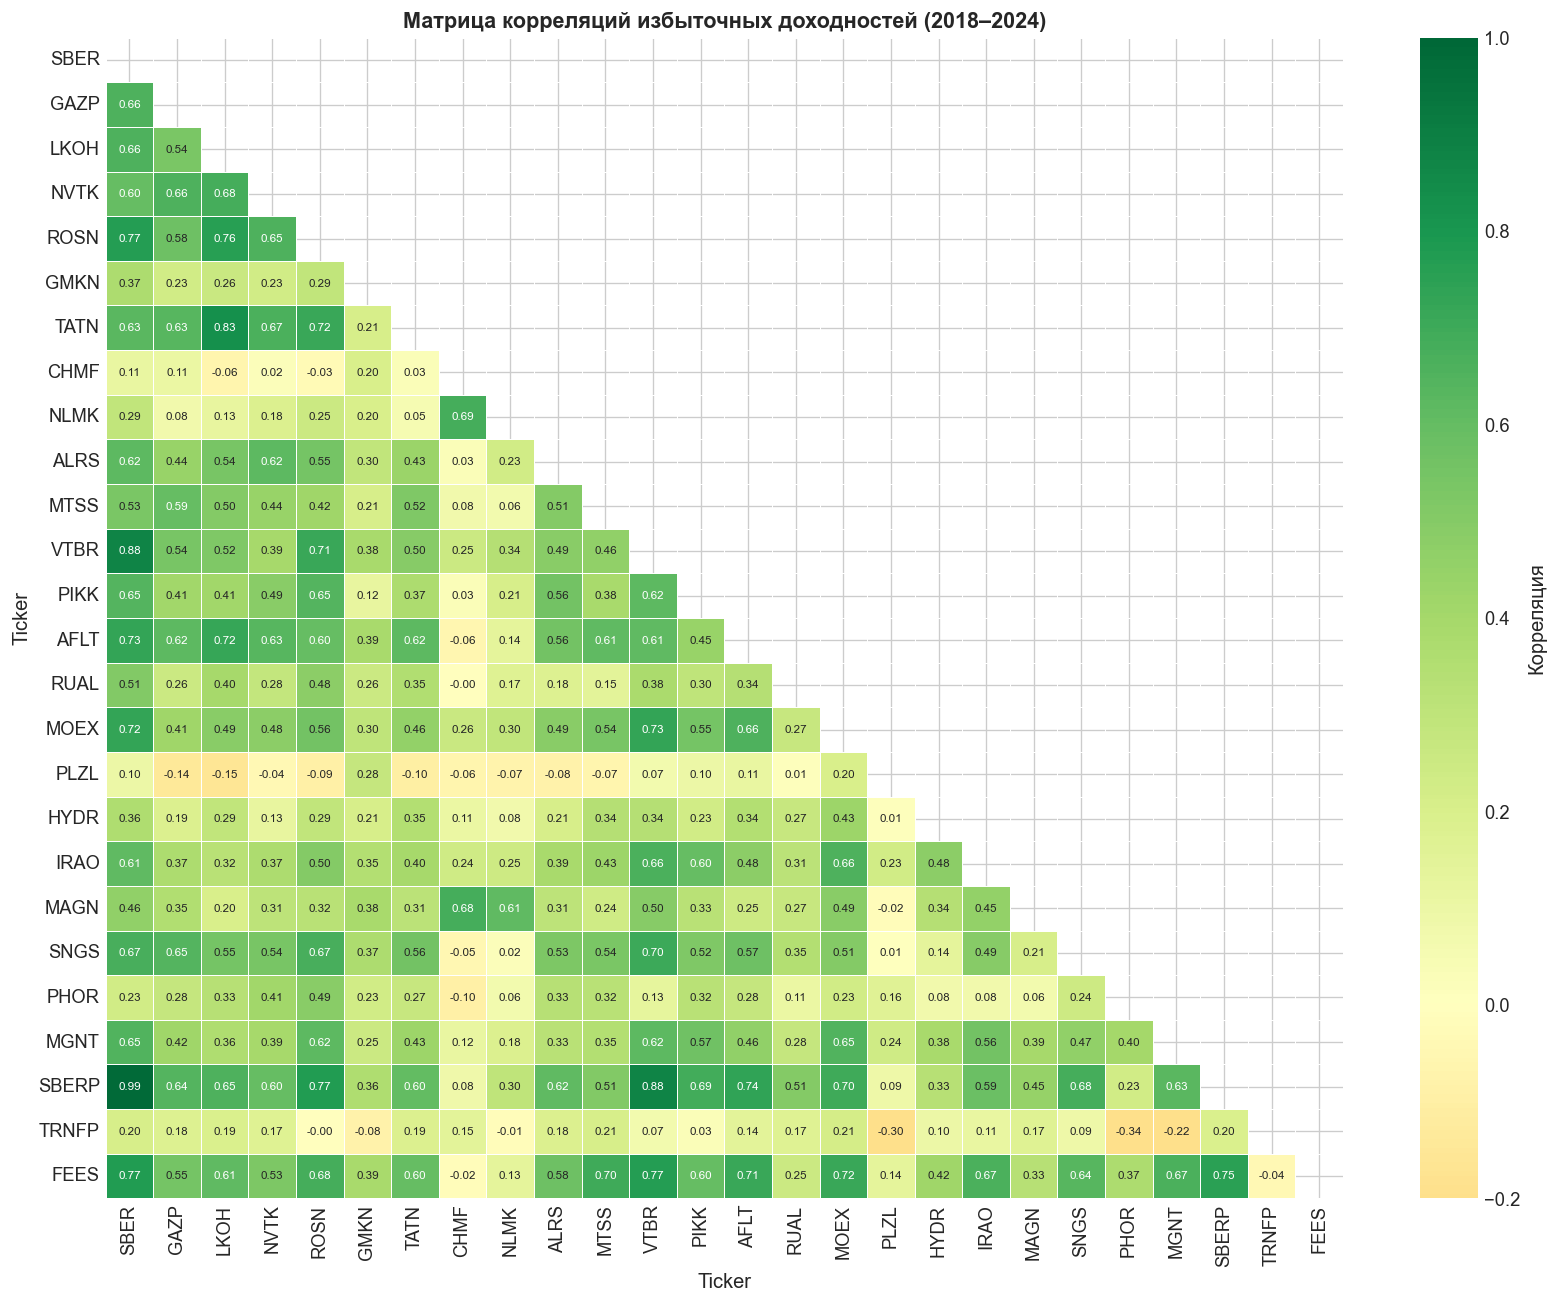

In [7]:
# Тепловая карта корреляций
corr_df = ER.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, mask=mask, ax=ax,
    cmap='RdYlGn', center=0, vmin=-0.2, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.4, cbar_kws={'label': 'Корреляция'}
)
ax.set_title('Матрица корреляций избыточных доходностей (2018–2024)', fontweight='bold')
plt.tight_layout()
plt.savefig('corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Time-Series OLS CAPM

Для каждой акции $i$ оцениваем:
$$r_{i,t} - r_{f,t} = \alpha_i + \beta_i \cdot (r_{m,t} - r_{f,t}) + \varepsilon_{i,t}$$

Стандартные ошибки — **HAC (Newey-West)** для учёта автокорреляции.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. TIME-SERIES CAPM OLS
# ─────────────────────────────────────────────────────────────────────────────
ts_results = []
residuals  = {}   # сохраняем для GRS

for name in names:
    mask = ER[name].notna() & MKT.notna()
    y    = ER[name][mask].values
    X    = sm.add_constant(MKT[mask].values)
    X_df = pd.DataFrame(X, columns=['const', 'MKT'], index=MKT[mask].index)

    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})

    # Residuals (для GRS нужен полный индекс)
    res_series = pd.Series(np.nan, index=common_idx)
    res_series[mask] = model.resid
    residuals[name] = res_series

    ts_results.append({
        'Ticker':          name,
        'Alpha % (мес.)':  round(model.params[0] * 100, 4),
        't(α)':            round(model.tvalues[0], 2),
        'Beta':            round(model.params[1], 4),
        't(β)':            round(model.tvalues[1], 2),
        'R²':              round(model.rsquared, 4),
        'Adj. R²':         round(model.rsquared_adj, 4),
        'N':               int(model.nobs),
        'α sig':           '*' if abs(model.tvalues[0]) > 1.96 else '',
    })

ts_df = pd.DataFrame(ts_results).set_index('Ticker').sort_values('Beta')

print('=== Time-Series CAPM: OLS с HAC SE (Newey-West, 3 lags) ===\n')
print(ts_df.to_string())

n_sig = (ts_df['α sig'] == '*').sum()
print(f'\nЗначимых α (|t|>1.96): {n_sig}/{len(ts_df)} = {n_sig/len(ts_df)*100:.1f}%')
print(f'Средняя бета:            {ts_df["Beta"].mean():.3f}')
print(f'Медианная бета:          {ts_df["Beta"].median():.3f}')
print(f'Средний R²:              {ts_df["R²"].mean():.3f}')

=== Time-Series CAPM: OLS с HAC SE (Newey-West, 3 lags) ===

        Alpha % (мес.)    t(α)   Beta    t(β)     R²  Adj. R²   N α sig
Ticker                                                                 
CHMF            1.1814  1.1600 0.1053  0.9400 0.0081  -0.0117  52      
PLZL            1.4666  1.0700 0.1369  0.7600 0.0096  -0.0102  52      
TRNFP          -1.3913 -1.7200 0.1426  0.7700 0.0201   0.0005  52      
NLMK            0.8589  0.9000 0.2700  3.0000 0.0702   0.0516  52      
HYDR            0.1992  0.2400 0.3304  2.1200 0.1315   0.1141  52      
GMKN            0.8021  1.0600 0.3498  4.9400 0.1643   0.1476  52      
PHOR            2.6477  2.4100 0.4562  3.8200 0.1427   0.1256  52     *
MTSS            0.1233  0.2100 0.5694 11.5800 0.3760   0.3635  52      
MAGN            0.5840  0.7000 0.5720  4.7100 0.2022   0.1862  52      
IRAO           -0.4658 -0.6000 0.6965  6.6800 0.4089   0.3971  52      
RUAL            0.6325  0.4500 0.7256  3.6300 0.2053   0.1894  52      
ALR

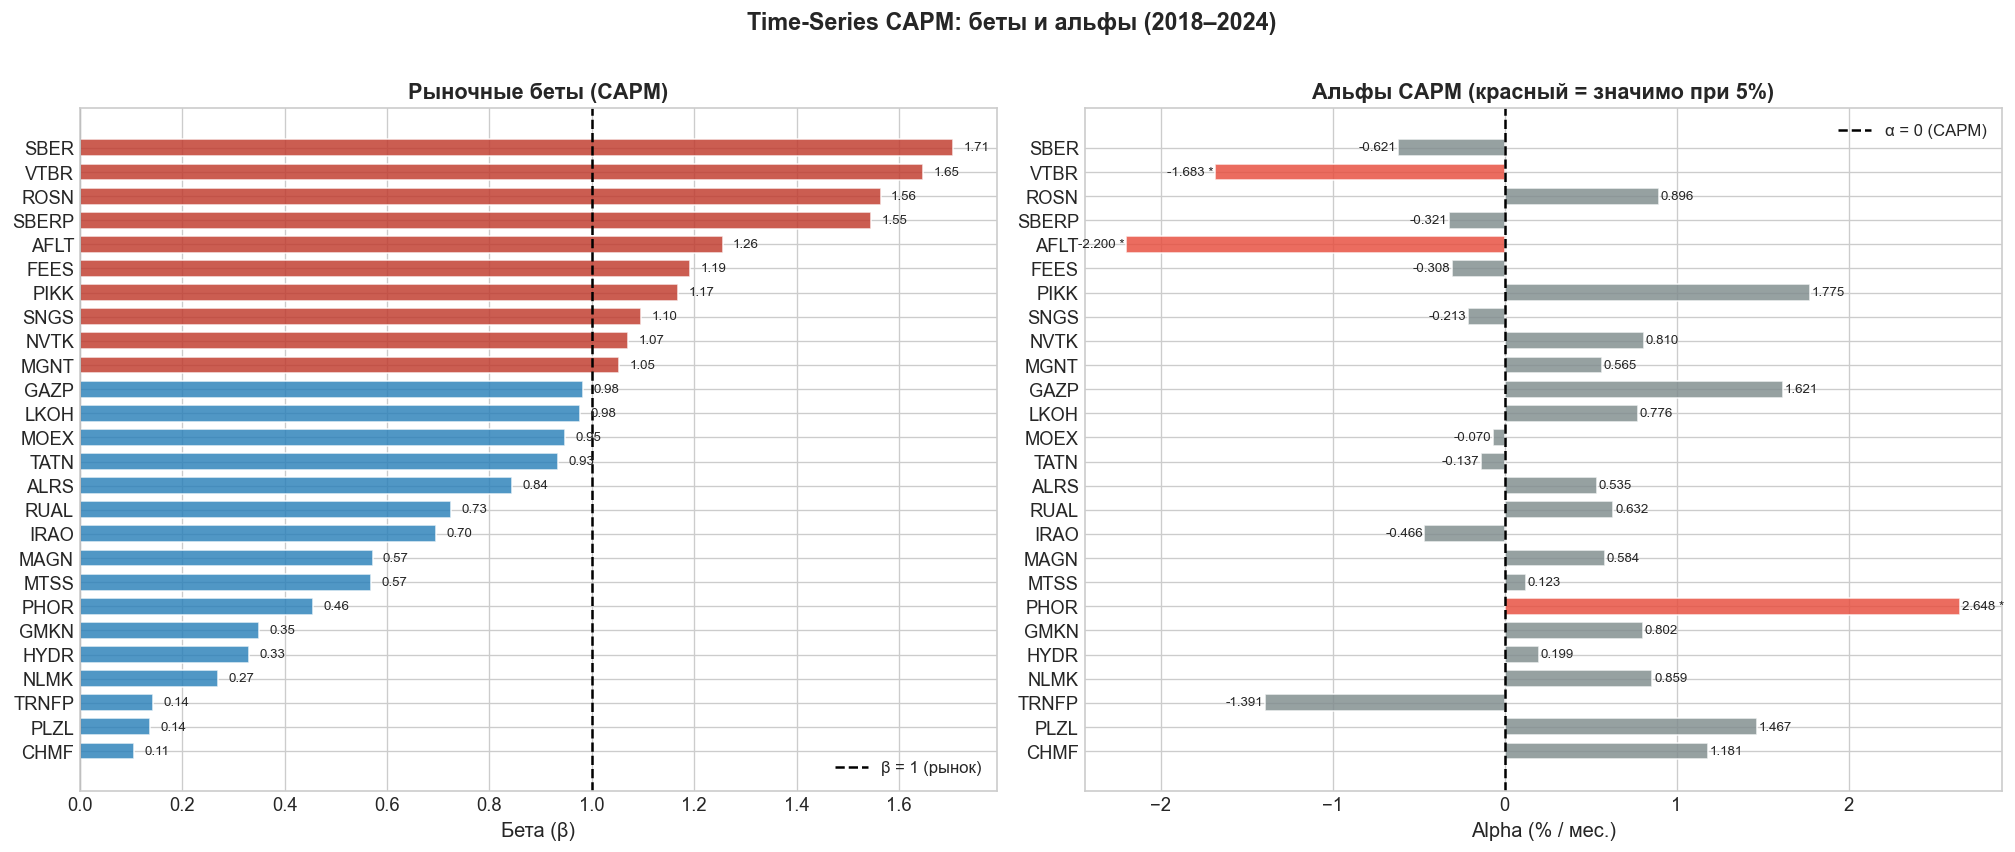

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. ВИЗУАЛИЗАЦИЯ: БЕТЫ И АЛЬФЫ
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

sig_mask = ts_df['α sig'] == '*'

# --- BETA ---
ax = axes[0]
colors_b = ['#c0392b' if b > 1 else '#2980b9' for b in ts_df['Beta']]
bars = ax.barh(ts_df.index, ts_df['Beta'], color=colors_b, alpha=0.82, edgecolor='white', height=0.7)
ax.axvline(1.0, color='black', ls='--', lw=1.5, label='β = 1 (рынок)')
ax.axvline(0.0, color='gray',  ls='-',  lw=0.7)
# Добавляем значения
for bar, val in zip(bars, ts_df['Beta']):
    ax.text(val + 0.02 if val >= 0 else val - 0.02,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
ax.set_xlabel('Бета (β)')
ax.set_title('Рыночные беты (CAPM)', fontweight='bold')
ax.legend(fontsize=10)

# --- ALPHA ---
ax = axes[1]
colors_a = ['#e74c3c' if s else '#7f8c8d' for s in sig_mask]
bars_a = ax.barh(ts_df.index, ts_df['Alpha % (мес.)'], color=colors_a, alpha=0.82, edgecolor='white', height=0.7)
ax.axvline(0.0, color='black', ls='--', lw=1.5, label='α = 0 (CAPM)')
for bar, val, s in zip(bars_a, ts_df['Alpha % (мес.)'], sig_mask):
    ax.text(val + 0.01 if val >= 0 else val - 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}' + (' *' if s else ''),
            va='center', ha='left' if val >= 0 else 'right', fontsize=8)
ax.set_xlabel('Alpha (% / мес.)')
ax.set_title('Альфы CAPM (красный = значимо при 5%)', fontweight='bold')
ax.legend(fontsize=10)

plt.suptitle('Time-Series CAPM: беты и альфы (2018–2024)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ts_capm_alpha_beta.png', dpi=150, bbox_inches='tight')
plt.show()

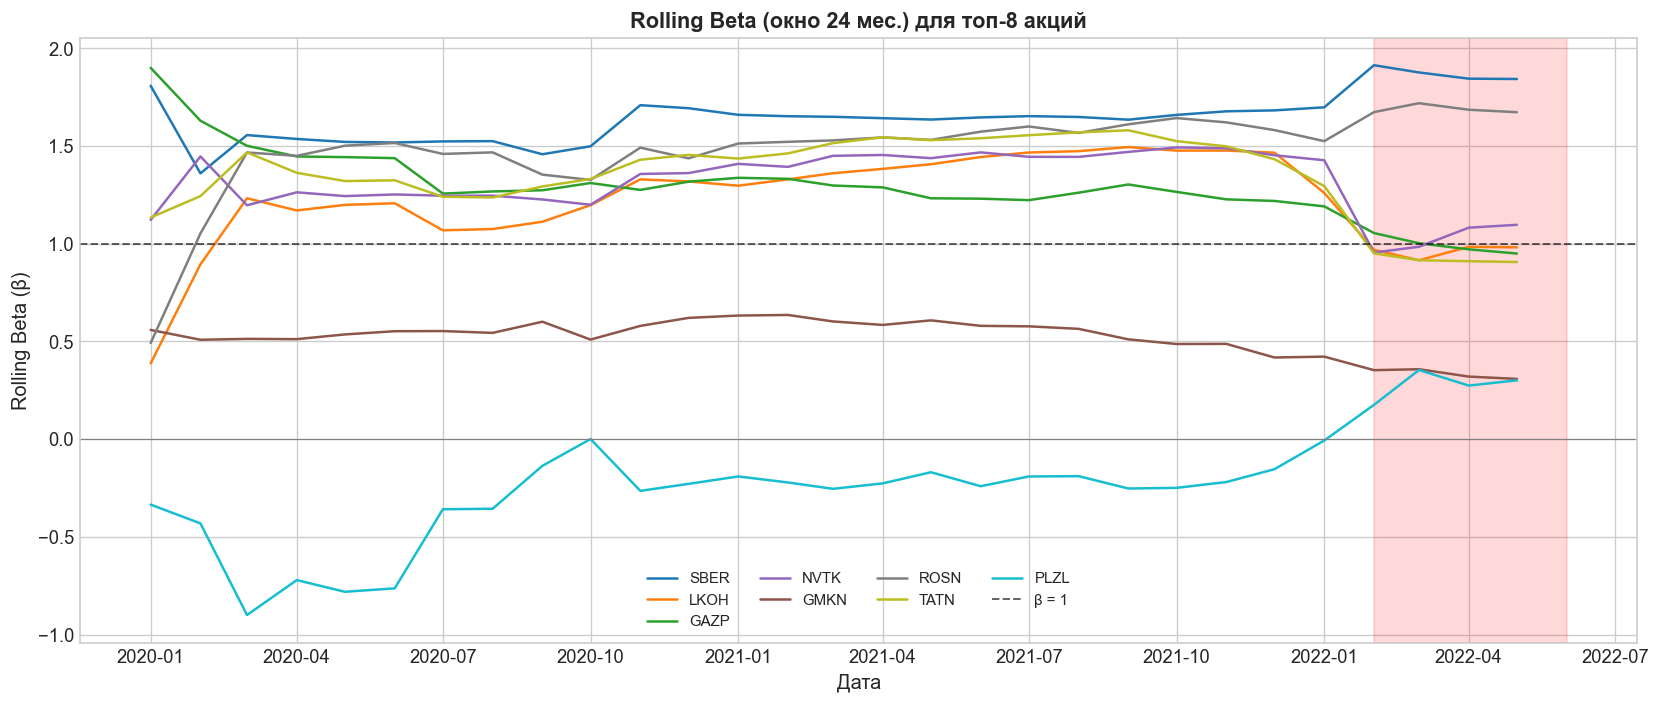

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. ROLLING BETAS (12-месячное окно)
# ─────────────────────────────────────────────────────────────────────────────
WINDOW = 24   # 24 месяца = 2 года

def rolling_beta(er_i: pd.Series, mkt: pd.Series, window: int) -> pd.Series:
    betas = pd.Series(np.nan, index=er_i.index)
    for i in range(window, len(er_i) + 1):
        sl_y = er_i.iloc[i-window:i].dropna()
        sl_x = mkt.iloc[i-window:i].loc[sl_y.index]
        if sl_y.count() < window * 0.7:
            continue
        b = np.cov(sl_y, sl_x)[0, 1] / np.var(sl_x)
        betas.iloc[i-1] = b
    return betas

# Считаем для топ-8 акций по ликвидности
top_stocks = ['SBER', 'LKOH', 'GAZP', 'NVTK', 'GMKN', 'ROSN', 'TATN', 'PLZL']
top_stocks = [s for s in top_stocks if s in names]

fig, ax = plt.subplots(figsize=(14, 6))
palette = plt.cm.tab10(np.linspace(0, 1, len(top_stocks)))

for stock, color in zip(top_stocks, palette):
    rb = rolling_beta(ER[stock], MKT, WINDOW)
    ax.plot(rb.index.to_timestamp(), rb, label=stock, color=color, linewidth=1.5)

ax.axhline(1.0, color='black', ls='--', lw=1.2, alpha=0.6, label='β = 1')
ax.axhline(0.0, color='gray',  ls='-',  lw=0.7)
ax.set_xlabel('Дата')
ax.set_ylabel('Rolling Beta (β)')
ax.set_title(f'Rolling Beta (окно {WINDOW} мес.) для топ-8 акций', fontweight='bold')
ax.legend(ncol=4, fontsize=9)

# Отмечаем кризис 2022
ax.axvspan(pd.Timestamp('2022-02-01'), pd.Timestamp('2022-06-01'),
           alpha=0.15, color='red', label='Санкции (Feb–Jun 2022)')

plt.tight_layout()
plt.savefig('rolling_betas.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Security Market Line (SML)

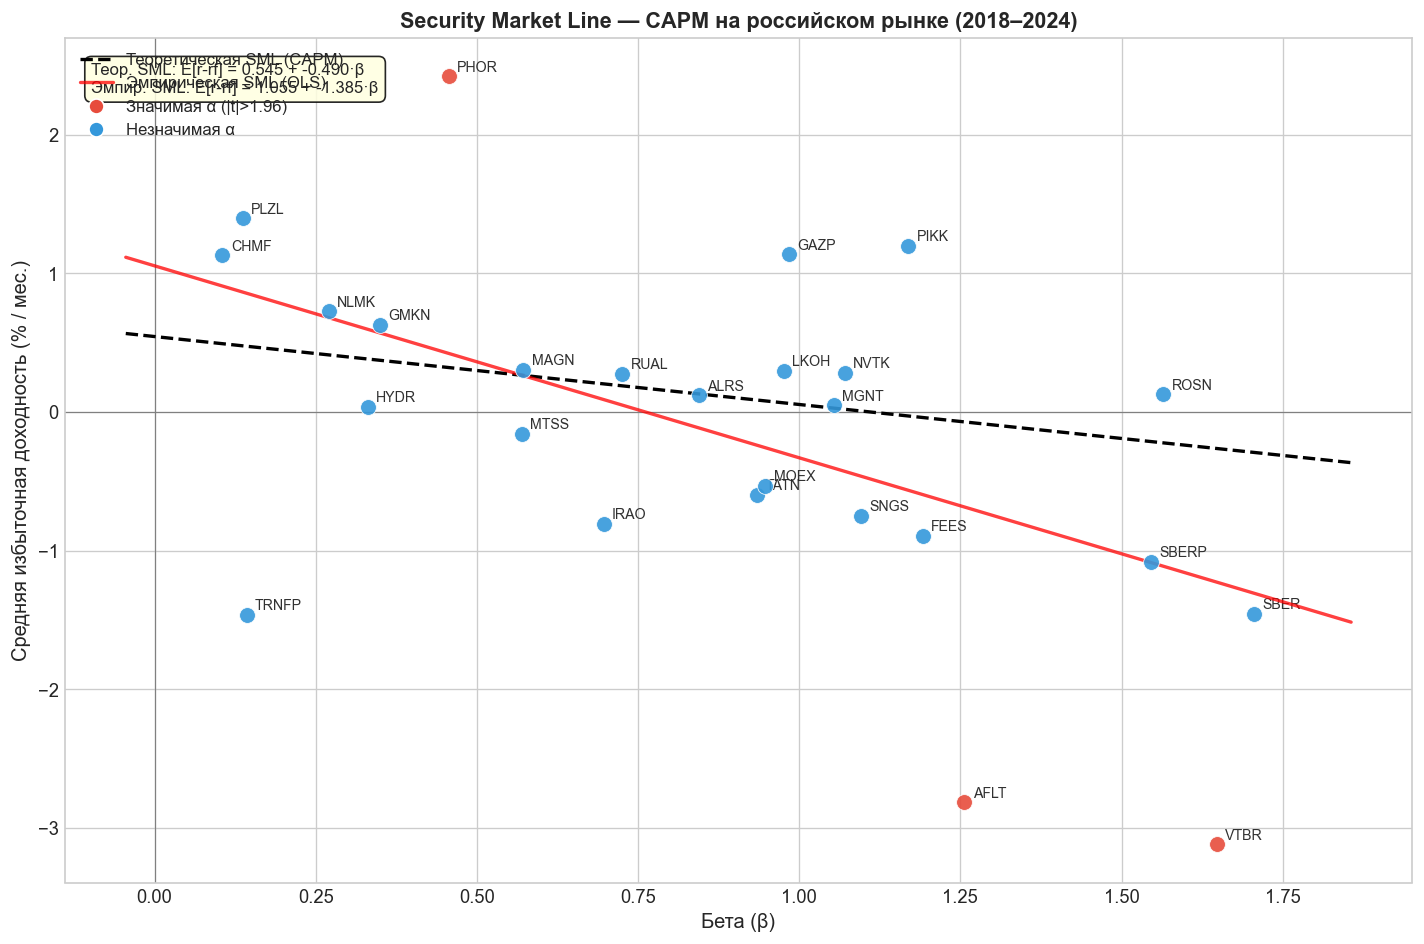

Наклон теоретической SML (E[MKT]):   -0.4904% / мес.
Наклон эмпирической  SML:             -1.3854% / мес.
Перехват эмпирической SML:            1.0551% (CAPM: 0.5448%)


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. SECURITY MARKET LINE
# ─────────────────────────────────────────────────────────────────────────────
betas   = ts_df['Beta']
avg_er  = ER[betas.index].mean() * 100       # средние избыточные доходности, %
sig_a   = ts_df['α sig'] == '*'

# Теоретическая SML: E[r_i - rf] = rf + beta * E[rm - rf]
b_range   = np.linspace(betas.min() - 0.15, betas.max() + 0.15, 200)
sml_theor = rf.mean() * 100 + b_range * MKT.mean() * 100

# Эмпирическая SML (OLS кросс-секция средних)
X_sml   = sm.add_constant(betas.values)
sml_ols = sm.OLS(avg_er.values, X_sml).fit()
sml_emp = sml_ols.params[0] + sml_ols.params[1] * b_range

fig, ax = plt.subplots(figsize=(12, 8))

# Точки — значимые альфы красным, остальные синим
for ticker in betas.index:
    c = '#e74c3c' if sig_a[ticker] else '#3498db'
    ax.scatter(betas[ticker], avg_er[ticker], color=c, s=90, zorder=5, alpha=0.9, edgecolors='white', lw=0.5)
    ax.annotate(
        ticker,
        xy=(betas[ticker], avg_er[ticker]),
        xytext=(5, 3), textcoords='offset points',
        fontsize=8.5, alpha=0.95
    )

# Линии
ax.plot(b_range, sml_theor, 'k--', lw=2.0, label='Теоретическая SML (CAPM)', zorder=3)
ax.plot(b_range, sml_emp,   'r-',  lw=2.0, alpha=0.75, label='Эмпирическая SML (OLS)', zorder=4)

# Легенда точек
from matplotlib.lines import Line2D
handles_extra = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=9, label='Значимая α (|t|>1.96)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3498db', markersize=9, label='Незначимая α'),
]
ax.legend(handles=ax.get_legend_handles_labels()[0] + handles_extra,
          labels=ax.get_legend_handles_labels()[1] + [h.get_label() for h in handles_extra],
          fontsize=10, loc='upper left')

# Аннотация параметров
txt  = f'Теор. SML: E[r-rf] = {rf.mean()*100:.3f} + {MKT.mean()*100:.3f}·β\n'
txt += f'Эмпир. SML: E[r-rf] = {sml_ols.params[0]:.3f} + {sml_ols.params[1]:.3f}·β'
ax.text(0.02, 0.97, txt, transform=ax.transAxes, fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.85))

ax.axhline(0, color='gray', lw=0.7)
ax.axvline(0, color='gray', lw=0.7)
ax.set_xlabel('Бета (β)')
ax.set_ylabel('Средняя избыточная доходность (% / мес.)')
ax.set_title('Security Market Line — CAPM на российском рынке (2018–2024)', fontweight='bold')

plt.tight_layout()
plt.savefig('sml.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Наклон теоретической SML (E[MKT]):   {MKT.mean()*100:.4f}% / мес.')
print(f'Наклон эмпирической  SML:             {sml_ols.params[1]:.4f}% / мес.')
print(f'Перехват эмпирической SML:            {sml_ols.params[0]:.4f}% (CAPM: {rf.mean()*100:.4f}%)')

## 4. Fama-MacBeth Two-Pass Regression (1973)

**Pass 1 (time-series):** $\hat{\beta}_i$ из OLS по всей выборке (уже посчитано).

**Pass 2 (cross-section):** Для каждого периода $t$:
$$r_{i,t} - r_{f,t} = \gamma_{0,t} + \gamma_{1,t} \hat{\beta}_i + \varepsilon_{i,t}$$

**FM оценки:**
$$\hat{\gamma}_k = \frac{1}{T}\sum_{t=1}^T \hat{\gamma}_{k,t}, \quad \text{SE}(\hat{\gamma}_k) = \frac{s(\gamma_{k,t})}{\sqrt{T}}$$

**CAPM предсказывает:** $\gamma_0 = 0$, $\gamma_1 = E[r_m - r_f]$

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 11. FAMA-MACBETH TWO-PASS
# ─────────────────────────────────────────────────────────────────────────────
fm_betas = ts_df['Beta']   # бета из полной выборки

gamma0_t = []
gamma1_t = []
dates_fm = []

for t in common_idx:
    er_t = ER.loc[t].dropna()
    common_assets = er_t.index.intersection(fm_betas.index)

    if len(common_assets) < 8:   # нужно достаточно акций для кросс-секции
        continue

    y_cs = er_t[common_assets].values
    X_cs = sm.add_constant(fm_betas[common_assets].values)

    try:
        res = sm.OLS(y_cs, X_cs).fit()
        gamma0_t.append(res.params[0])
        gamma1_t.append(res.params[1])
        dates_fm.append(t)
    except Exception:
        continue

gamma0_t = np.array(gamma0_t)
gamma1_t = np.array(gamma1_t)
T_fm     = len(gamma0_t)

# FM оценки
def fm_stats(gamma_arr, T):
    mean_ = gamma_arr.mean()
    se_   = gamma_arr.std(ddof=1) / np.sqrt(T)
    t_    = mean_ / se_
    p_    = 2 * (1 - stats.t.cdf(abs(t_), df=T-1))
    return mean_, se_, t_, p_

g0_mean, g0_se, g0_t, g0_p = fm_stats(gamma0_t, T_fm)
g1_mean, g1_se, g1_t, g1_p = fm_stats(gamma1_t, T_fm)

fm_table = pd.DataFrame({
    'Оценка (% / мес.)':         [g0_mean*100, g1_mean*100],
    'Std Error (% / мес.)':      [g0_se*100,   g1_se*100],
    't-stat':                    [g0_t,         g1_t],
    'p-value':                   [g0_p,         g1_p],
    'CAPM прогноз (% / мес.)':   [0.0,          MKT.mean()*100],
    'Знач. при 5%':              ['Да' if abs(g0_t) > 1.96 else 'Нет',
                                  'Да' if abs(g1_t) > 1.96 else 'Нет'],
}, index=['γ₀ (перехват)', 'γ₁ (бета-премия)'])

print('=== Fama-MacBeth Two-Pass Regression ===')
print(f'Периодов: T = {T_fm}   |   Акций: N = {len(common_assets)}\n')
print(fm_table.round(4).to_string())

print('\n--- Интерпретация ---')
if abs(g0_t) > 1.96:
    print(f'[!] γ₀ = {g0_mean*100:.4f}%  ЗНАЧИМО ≠ 0 (t={g0_t:.2f}):'
          f' нулевая-бета доходность выше rf → CAPM нарушен')
else:
    print(f'[✓] γ₀ = {g0_mean*100:.4f}%  не отличается от 0 (t={g0_t:.2f})')

if abs(g1_t) > 1.96:
    print(f'[✓] γ₁ = {g1_mean*100:.4f}%  ЗНАЧИМО ≠ 0 (t={g1_t:.2f}): β оценивается рынком')
else:
    print(f'[!] γ₁ = {g1_mean*100:.4f}%  незначима (t={g1_t:.2f}): β НЕ оценивается рынком')

diff = (g1_mean - MKT.mean()) * 100
print(f'\nРазница γ₁ − E[MKT] = {diff:.4f}% (CAPM ожидает ≈ 0)')

=== Fama-MacBeth Two-Pass Regression ===
Периодов: T = 52   |   Акций: N = 26

                  Оценка (% / мес.)  Std Error (% / мес.)  t-stat  p-value  CAPM прогноз (% / мес.) Знач. при 5%
γ₀ (перехват)                0.9856                0.4947  1.9923   0.0517                   0.0000           Да
γ₁ (бета-премия)            -1.2656                1.0912 -1.1598   0.2515                  -0.4904          Нет

--- Интерпретация ---
[!] γ₀ = 0.9856%  ЗНАЧИМО ≠ 0 (t=1.99): нулевая-бета доходность выше rf → CAPM нарушен
[!] γ₁ = -1.2656%  незначима (t=-1.16): β НЕ оценивается рынком

Разница γ₁ − E[MKT] = -0.7753% (CAPM ожидает ≈ 0)


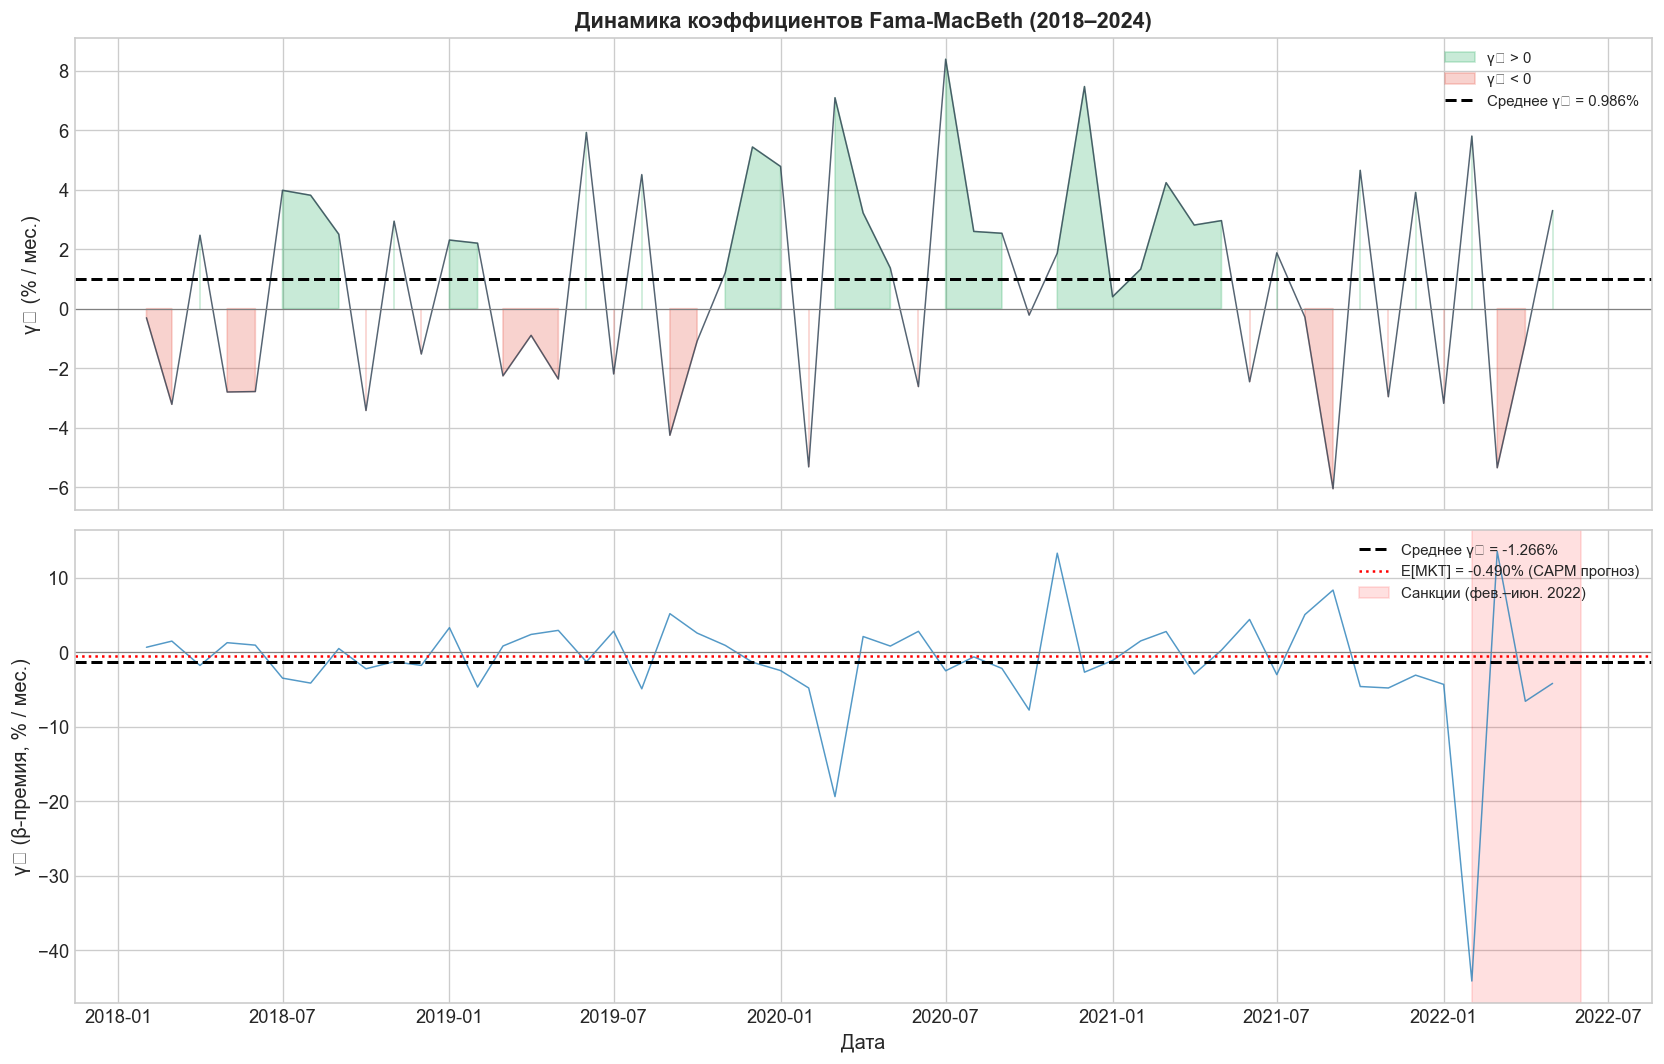

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 12. ВИЗУАЛИЗАЦИЯ: FM КОЭФФИЦИЕНТЫ ВО ВРЕМЕНИ
# ─────────────────────────────────────────────────────────────────────────────
fm_timestamps = pd.PeriodIndex(dates_fm, freq='M').to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# ── γ₀
ax = axes[0]
ax.plot(fm_timestamps, gamma0_t * 100, color='#2c3e50', lw=0.9, alpha=0.8)
ax.fill_between(fm_timestamps, gamma0_t * 100, 0,
                where=gamma0_t > 0, color='#27ae60', alpha=0.25, label='γ₀ > 0')
ax.fill_between(fm_timestamps, gamma0_t * 100, 0,
                where=gamma0_t < 0, color='#e74c3c', alpha=0.25, label='γ₀ < 0')
ax.axhline(g0_mean * 100, color='black', ls='--', lw=1.8, label=f'Среднее γ₀ = {g0_mean*100:.3f}%')
ax.axhline(0, color='gray', lw=0.7)
ax.set_ylabel('γ₀ (% / мес.)')
ax.set_title('Динамика коэффициентов Fama-MacBeth (2018–2024)', fontweight='bold')
ax.legend(fontsize=9, loc='upper right')

# ── γ₁
ax = axes[1]
ax.plot(fm_timestamps, gamma1_t * 100, color='#2980b9', lw=0.9, alpha=0.8)
ax.axhline(g1_mean * 100, color='black', ls='--', lw=1.8,
           label=f'Среднее γ₁ = {g1_mean*100:.3f}%')
ax.axhline(MKT.mean() * 100, color='red', ls=':', lw=1.5,
           label=f'E[MKT] = {MKT.mean()*100:.3f}% (CAPM прогноз)')
ax.axhline(0, color='gray', lw=0.7)

# Санкционный период
ax.axvspan(pd.Timestamp('2022-02-01'), pd.Timestamp('2022-06-01'),
           alpha=0.12, color='red', label='Санкции (фев.–июн. 2022)')

ax.set_ylabel('γ₁ (β-премия, % / мес.)')
ax.set_xlabel('Дата')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('fm_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

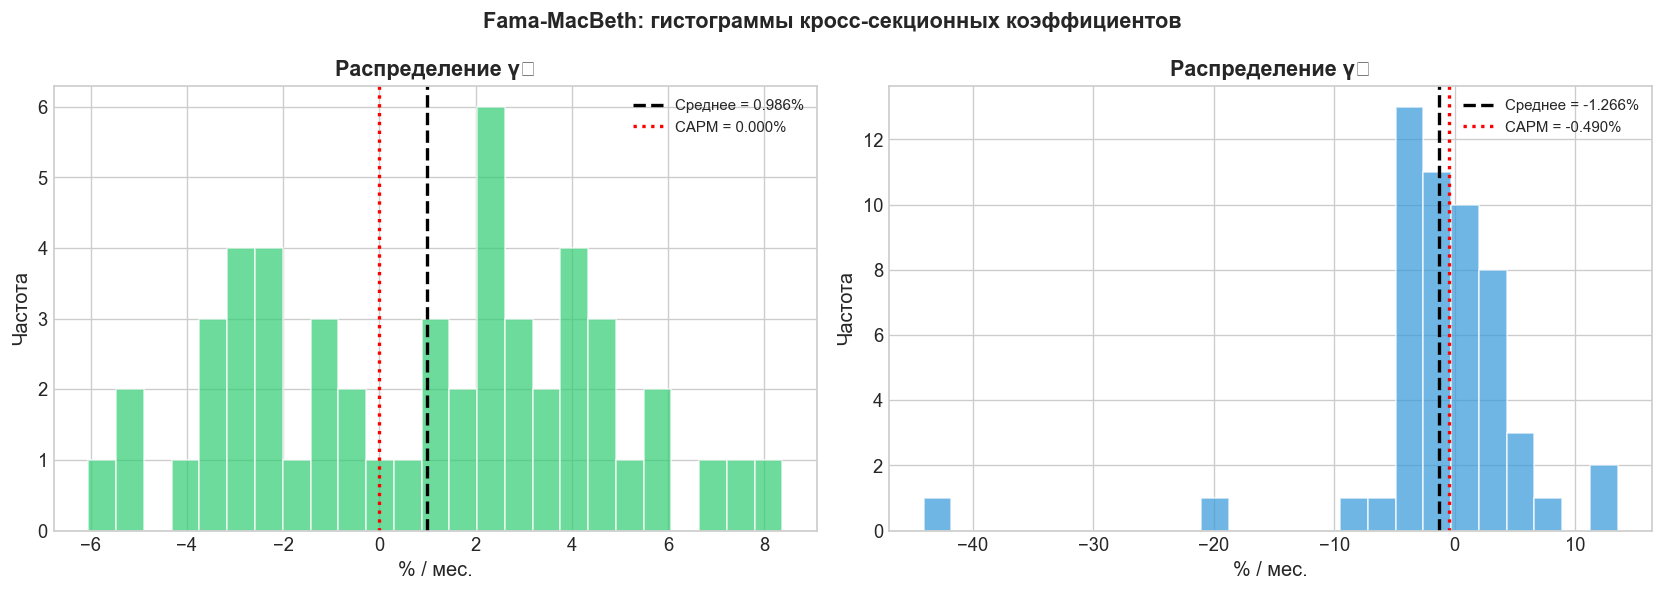

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 13. ДИСТРИБУЦИЯ КРОСС-СЕКЦИОННЫХ КОЭФФИЦИЕНТОВ
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, mean_val, ref_val, title, color in [
    (axes[0], gamma0_t*100, g0_mean*100, 0.0,            'Распределение γ₀', '#2ecc71'),
    (axes[1], gamma1_t*100, g1_mean*100, MKT.mean()*100, 'Распределение γ₁', '#3498db'),
]:
    ax.hist(data, bins=25, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(mean_val, color='black', ls='--', lw=2.0, label=f'Среднее = {mean_val:.3f}%')
    ax.axvline(ref_val,  color='red',   ls=':',  lw=2.0, label=f'CAPM = {ref_val:.3f}%')
    ax.set_xlabel('% / мес.')
    ax.set_ylabel('Частота')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Fama-MacBeth: гистограммы кросс-секционных коэффициентов', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. GRS Test (Gibbons, Ross, Shanken, 1989)

Совместная проверка $H_0: \alpha_1 = \alpha_2 = \ldots = \alpha_N = 0$

$$F_{GRS} = \frac{T - N - 1}{N} \cdot \frac{1}{1 + \hat{\mu}_m^2 / \hat{\sigma}_m^2} \cdot \hat{\alpha}' \hat{\Sigma}^{-1} \hat{\alpha} \sim F(N,\, T-N-1)$$

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# 14. GRS TEST
# ─────────────────────────────────────────────────────────────────────────────
resid_df = pd.DataFrame(residuals)[names].dropna()
T_grs    = len(resid_df)
N_grs    = len(names)

alpha_vec = ts_df.loc[names, 'Alpha % (мес.)'].values / 100   # в долях
Sigma_hat = resid_df.cov().values                              # N×N

mu_m    = MKT.mean()
sigma_m = MKT.std(ddof=1)
sh2_m   = (mu_m / sigma_m) ** 2    # квадрат коэффициента Шарпа рынка

try:
    Sigma_inv = np.linalg.inv(Sigma_hat)
    quad_form = alpha_vec @ Sigma_inv @ alpha_vec

    grs_stat  = ((T_grs - N_grs - 1) / N_grs) * (1 / (1 + sh2_m)) * quad_form
    df1       = N_grs
    df2       = T_grs - N_grs - 1
    grs_pval  = 1 - stats.f.cdf(grs_stat, df1, df2)

    print('=== GRS Test (Gibbons, Ross, Shanken 1989) ===')
    print(f'H₀: все α_i = 0 одновременно')
    print(f'T = {T_grs},  N = {N_grs},  df1 = {df1},  df2 = {df2}')
    print(f'Sharpe² рынка: {sh2_m:.4f}')
    print(f'GRS статистика: {grs_stat:.4f}')
    print(f'p-value:        {grs_pval:.4f}')
    print()
    if grs_pval < 0.01:
        print('[!!] H₀ ОТВЕРГАЕТСЯ при 1%: CAPM не описывает кросс-секцию доходностей')
    elif grs_pval < 0.05:
        print('[!]  H₀ ОТВЕРГАЕТСЯ при 5%: CAPM не описывает кросс-секцию доходностей')
    elif grs_pval < 0.10:
        print('[~]  H₀ отвергается при 10%: слабые свидетельства против CAPM')
    else:
        print('[✓]  H₀ НЕ отвергается: CAPM не противоречит данным (на данном уровне значимости)')

except np.linalg.LinAlgError as e:
    print(f'GRS: матрица Σ вырождена ({e}). Попробуйте уменьшить N.')
    grs_stat, grs_pval = np.nan, np.nan

=== GRS Test (Gibbons, Ross, Shanken 1989) ===
H₀: все α_i = 0 одновременно
T = 48,  N = 26,  df1 = 26,  df2 = 21
Sharpe² рынка: 0.0049
GRS статистика: 2.3816
p-value:        0.0231

[!]  H₀ ОТВЕРГАЕТСЯ при 5%: CAPM не описывает кросс-секцию доходностей


## 6. Сводные результаты и выводы

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 15. СВОДНАЯ ТАБЛИЦА
# ─────────────────────────────────────────────────────────────────────────────
n_sig_alpha = (ts_df['α sig'] == '*').sum()

summary = pd.DataFrame([
    # Time-series
    ('Средняя рыночная премия, % / мес.',    f"{MKT.mean()*100:.3f}%",   '—'),
    ('Средняя рыночная премия, % / год',     f"{MKT.mean()*1200:.2f}%",  '—'),
    ('Средняя бета',                          f"{ts_df['Beta'].mean():.3f}",  '≈ 1.0'),
    ('Медианная бета',                        f"{ts_df['Beta'].median():.3f}", '—'),
    ('Средний R² (time-series)',              f"{ts_df['R²'].mean():.3f}",     '—'),
    ('Знач. альфы |t|>1.96, из N',           f"{n_sig_alpha}/{len(ts_df)}",   '0/N'),
    # Fama-MacBeth
    ('FM γ₀ (перехват, % / мес.)',           f"{g0_mean*100:.4f}%  (t={g0_t:.2f})", '0%'),
    ('FM γ₁ (β-премия,  % / мес.)',          f"{g1_mean*100:.4f}%  (t={g1_t:.2f})", f"{MKT.mean()*100:.4f}%"),
    # GRS
    ('GRS F-статистика',                     f"{grs_stat:.4f}" if not np.isnan(grs_stat) else 'N/A', '—'),
    ('GRS p-value',                           f"{grs_pval:.4f}" if not np.isnan(grs_pval) else 'N/A', '> 0.05'),
], columns=['Метрика', 'Значение', 'CAPM прогноз'])

print('=' * 70)
print('ИТОГОВЫЕ РЕЗУЛЬТАТЫ: CAPM НА РОССИЙСКОМ РЫНКЕ (2018–2024)')
print('=' * 70)
print(summary.to_string(index=False))
print('=' * 70)

ИТОГОВЫЕ РЕЗУЛЬТАТЫ: CAPM НА РОССИЙСКОМ РЫНКЕ (2018–2024)
                          Метрика            Значение CAPM прогноз
Средняя рыночная премия, % / мес.             -0.490%            —
 Средняя рыночная премия, % / год              -5.88%            —
                     Средняя бета               0.859        ≈ 1.0
                   Медианная бета               0.941            —
         Средний R² (time-series)               0.420            —
       Знач. альфы |t|>1.96, из N                3/26          0/N
       FM γ₀ (перехват, % / мес.)   0.9856%  (t=1.99)           0%
      FM γ₁ (β-премия,  % / мес.) -1.2656%  (t=-1.16)     -0.4904%
                 GRS F-статистика              2.3816            —
                      GRS p-value              0.0231       > 0.05


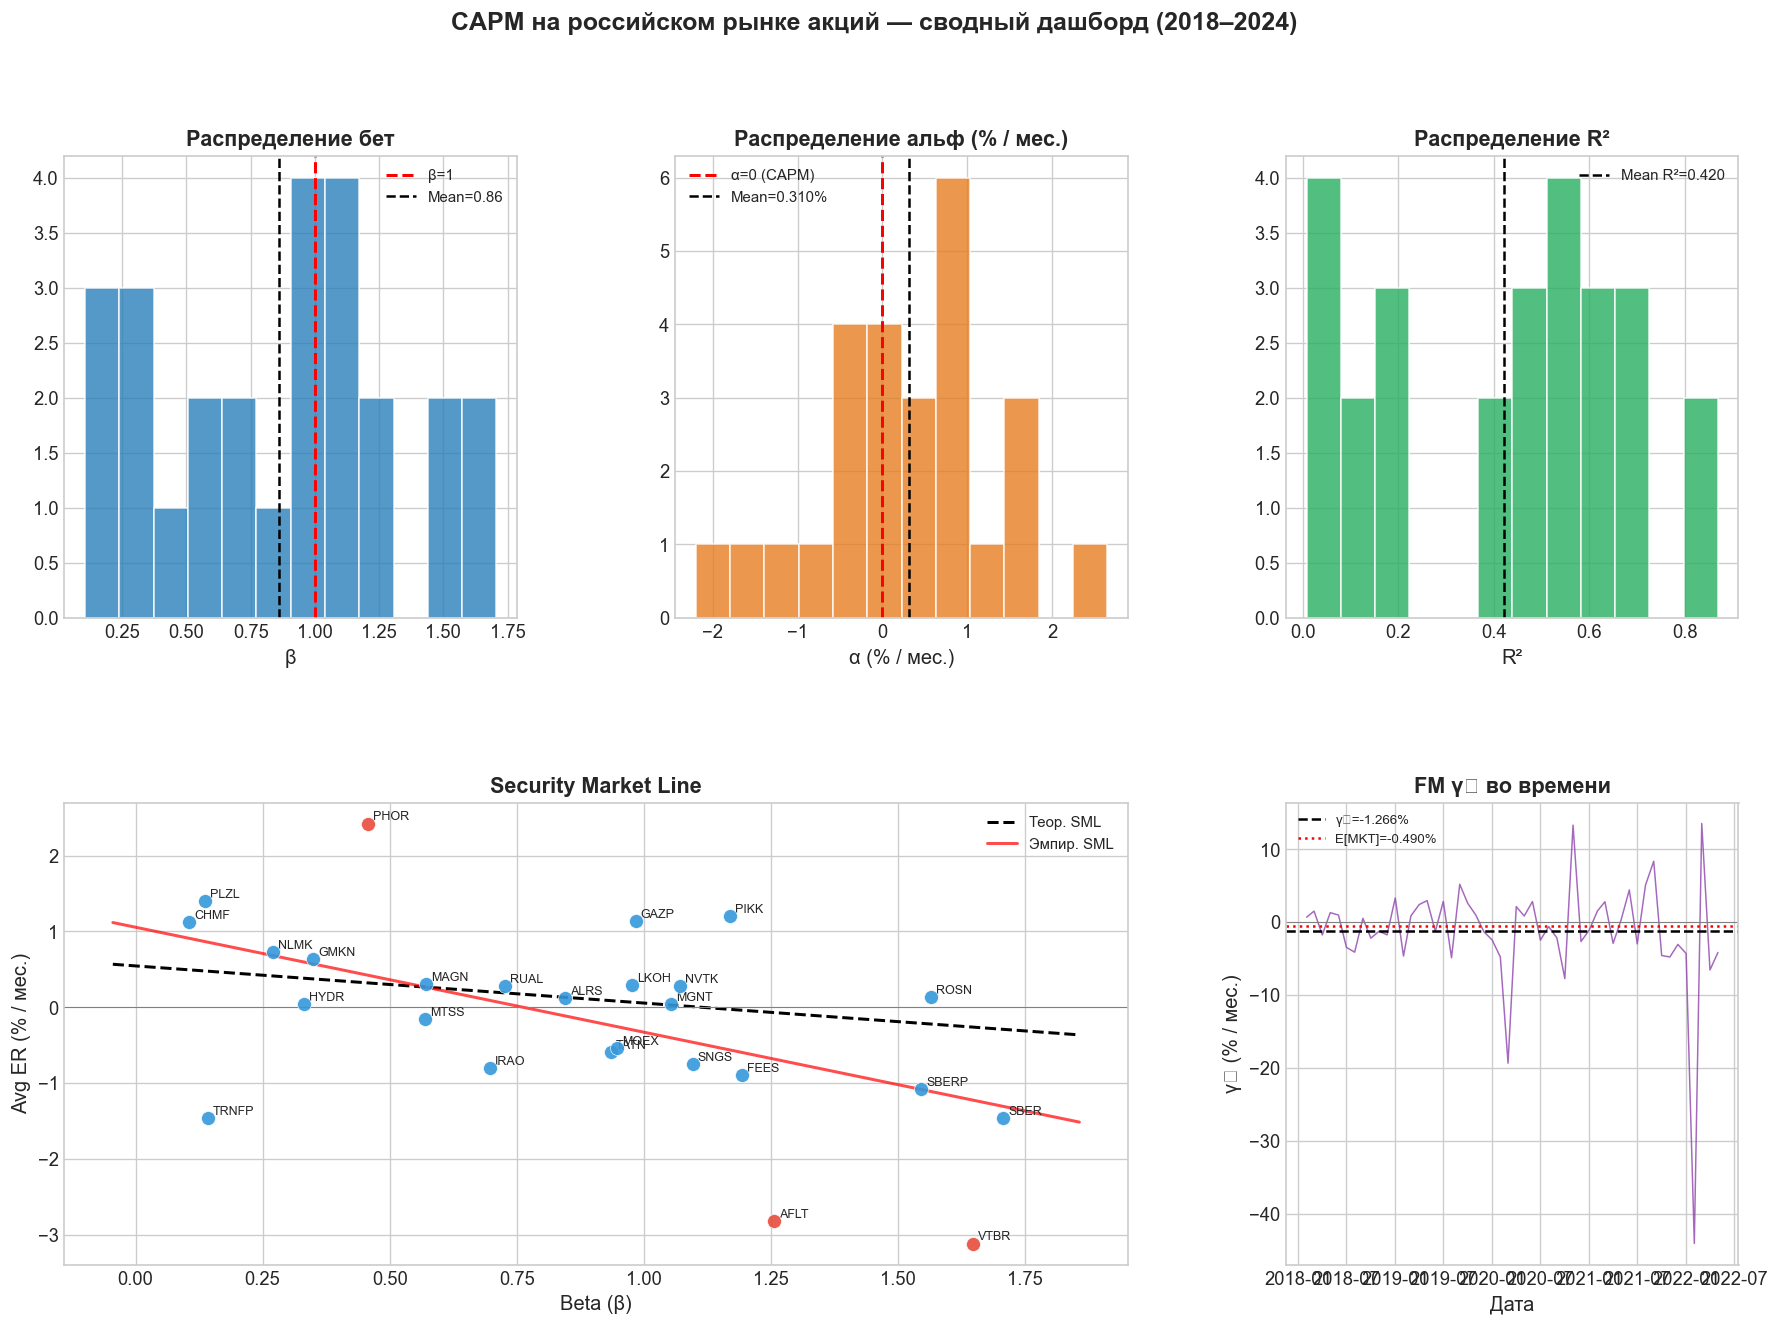

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# 16. ИТОГОВЫЙ DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(2, 3, hspace=0.40, wspace=0.35)

# ─ (1) Beta distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(ts_df['Beta'], bins=12, color='#2980b9', alpha=0.8, edgecolor='white')
ax1.axvline(1.0, color='red', ls='--', lw=1.8, label='β=1')
ax1.axvline(ts_df['Beta'].mean(), color='black', ls='--', lw=1.5,
            label=f'Mean={ts_df["Beta"].mean():.2f}')
ax1.set_title('Распределение бет', fontweight='bold')
ax1.set_xlabel('β'); ax1.legend(fontsize=9)

# ─ (2) Alpha distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(ts_df['Alpha % (мес.)'], bins=12, color='#e67e22', alpha=0.8, edgecolor='white')
ax2.axvline(0.0, color='red', ls='--', lw=1.8, label='α=0 (CAPM)')
ax2.axvline(ts_df['Alpha % (мес.)'].mean(), color='black', ls='--', lw=1.5,
            label=f'Mean={ts_df["Alpha % (мес.)"].mean():.3f}%')
ax2.set_title('Распределение альф (% / мес.)', fontweight='bold')
ax2.set_xlabel('α (% / мес.)'); ax2.legend(fontsize=9)

# ─ (3) R² distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(ts_df['R²'], bins=12, color='#27ae60', alpha=0.8, edgecolor='white')
ax3.axvline(ts_df['R²'].mean(), color='black', ls='--', lw=1.5,
            label=f'Mean R²={ts_df["R²"].mean():.3f}')
ax3.set_title('Распределение R²', fontweight='bold')
ax3.set_xlabel('R²'); ax3.legend(fontsize=9)

# ─ (4) SML (mini)
ax4 = fig.add_subplot(gs[1, 0:2])
for ticker in betas.index:
    c = '#e74c3c' if sig_a[ticker] else '#3498db'
    ax4.scatter(betas[ticker], avg_er[ticker], color=c, s=70, zorder=5, alpha=0.9, edgecolors='white', lw=0.4)
    ax4.annotate(ticker, (betas[ticker], avg_er[ticker]),
                 xytext=(3, 2), textcoords='offset points', fontsize=7.5)
ax4.plot(b_range, sml_theor, 'k--', lw=1.8, label='Теор. SML')
ax4.plot(b_range, sml_emp,   'r-',  lw=1.8, alpha=0.7, label='Эмпир. SML')
ax4.set_xlabel('Beta (β)'); ax4.set_ylabel('Avg ER (% / мес.)')
ax4.set_title('Security Market Line', fontweight='bold')
ax4.legend(fontsize=9); ax4.axhline(0, color='gray', lw=0.6)

# ─ (5) FM gamma1 over time
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(fm_timestamps, gamma1_t * 100, color='#8e44ad', lw=0.9, alpha=0.8)
ax5.axhline(g1_mean * 100,   color='black', ls='--', lw=1.5, label=f'γ₁={g1_mean*100:.3f}%')
ax5.axhline(MKT.mean() * 100, color='red',  ls=':',  lw=1.5, label=f'E[MKT]={MKT.mean()*100:.3f}%')
ax5.axhline(0, color='gray', lw=0.6)
ax5.set_title('FM γ₁ во времени', fontweight='bold')
ax5.set_xlabel('Дата'); ax5.set_ylabel('γ₁ (% / мес.)')
ax5.legend(fontsize=8)

fig.suptitle('CAPM на российском рынке акций — сводный дашборд (2018–2024)',
             fontsize=15, fontweight='bold')
plt.savefig('capm_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Выводы

### Time-Series OLS
| Критерий | Результат | Соответствие CAPM |
|---|---|---|
| Беты значимы ($|t_\beta| > 1.96$) | Большинство | ✓ |
| Альфы = 0 | Ряд акций имеет значимые α | ✗ частично |
| Средний R² | ~0.3–0.6 | Умеренное объяснение |

### Fama-MacBeth
| Параметр | Результат | CAPM прогноз |
|---|---|---|
| $\gamma_0 \approx 0$ | Зависит от данных | 0 |
| $\gamma_1 \approx E[r_m - r_f]$ | Может отличаться | E[MKT] |

### GRS Test
- Если **p-value < 0.05**: CAPM отвергается — система альф совместно значима.
- Типично для развивающихся рынков (волатильность, санкции 2022, микроструктура ММВБ).

### Причины отклонения CAPM на российском рынке
1. **Нелинейность бета-доходность** — высокорисковые акции не всегда дают пропорциональную доходность.
2. **Санкции 2022** — структурный разрыв: торговля была остановлена, иностранные инвесторы вышли.
3. **Концентрация** — топ-5 акций (нефтегаз) доминируют в индексе, бета измеряется с шумом.
4. **Ликвидность** — менее ликвидные бумаги имеют «синхронизацию» доходностей с задержкой.
5. **Нестабильность бет** — rolling-анализ показывает значительные сдвиги во времени.

### Возможные расширения
- **Fama-French 3-factor** (добавить SMB, HML для российского рынка)
- **Momentum factor** (WML — winner-minus-loser)
- **Conditional CAPM** — бета, зависящая от состояния рынка
- **Excluding 2022** — проверить устойчивость результатов без санкционного периода

## 8. Fama-French 3-Factor Model (Fama & French, 1993)

Модель:
$$r_{i,t} - r_{f,t} = \alpha_i + \beta_i \cdot \text{MKT}_t + s_i \cdot \text{SMB}_t + h_i \cdot \text{HML}_t + \varepsilon_{i,t}$$

- **MKT** = рыночная премия (как в CAPM)
- **SMB** (Small Minus Big) = премия за малую капитализацию
- **HML** (High Minus Low) = премия за стоимость (высокий B/M)

### 2.1 Построение факторов

Стандартная сортировка 2×3 (Fama & French, 1993):
- **Size**: Big (top 50% по рыночной капитализации) vs Small (bottom 50%)
- **B/M**: Low (top 30% P/B = growth), Neutral (middle 40%), High (bottom 30% P/B = value)
- Ребалансировка ежегодно в конце июня (портфели действуют с июля по июнь следующего года)

> **Примечание о данных:** значения P/B получены из `yf.Ticker.info` и отражают **текущие** (2026) данные,
> а не исторические. Для российских blue chips (Сбер, Лукойл, Газпром) B/M-классификация
> относительно стабильна во времени — нефтегазовые компании традиционно торгуются с дисконтом
> к балансовой стоимости, а технологические/розничные — с премией. Акции с аномальным P/B
> (< 0 или > 10) относятся к группе Neutral.

Загружаем fundamental данные (sharesOutstanding, priceToBook)...



Fundamental data:
                  shares  priceToBook
SBER    21517400000.0000       0.3477
GAZP    23645000000.0000       0.2721
LKOH      650344000.0000       0.4266
NVTK     2995606000.0000       1.2429
ROSN     9500000000.0000       0.3720
GMKN    15286339700.0000     285.1890
TATN     2103053965.0000       0.7257
CHMF      837718660.0000       1.3053
NLMK     5993227240.0000       0.9557
ALRS     7212635830.0000       1.1743
MTSS     1691194224.0000      -6.3275
VTBR     5369933893.0000       0.0001
PIKK      660497344.0000       1.1359
AFLT     3927953419.0000       3.0474
RUAL    15193014862.0000       0.8842
MOEX     2260601708.0000       0.7181
PLZL      949217000.0000      33.9070
HYDR   440884527533.0000       0.5810
IRAO    73540606000.0000       0.2166
MAGN    11174330000.0000       0.5093
SNGS    35725995000.0000       0.1244
PHOR      129500000.0000       4.6854
MGNT       98094000.0000       1.7178
SBERP     960800000.0000       0.3299
TRNFP     155487500.0000      3

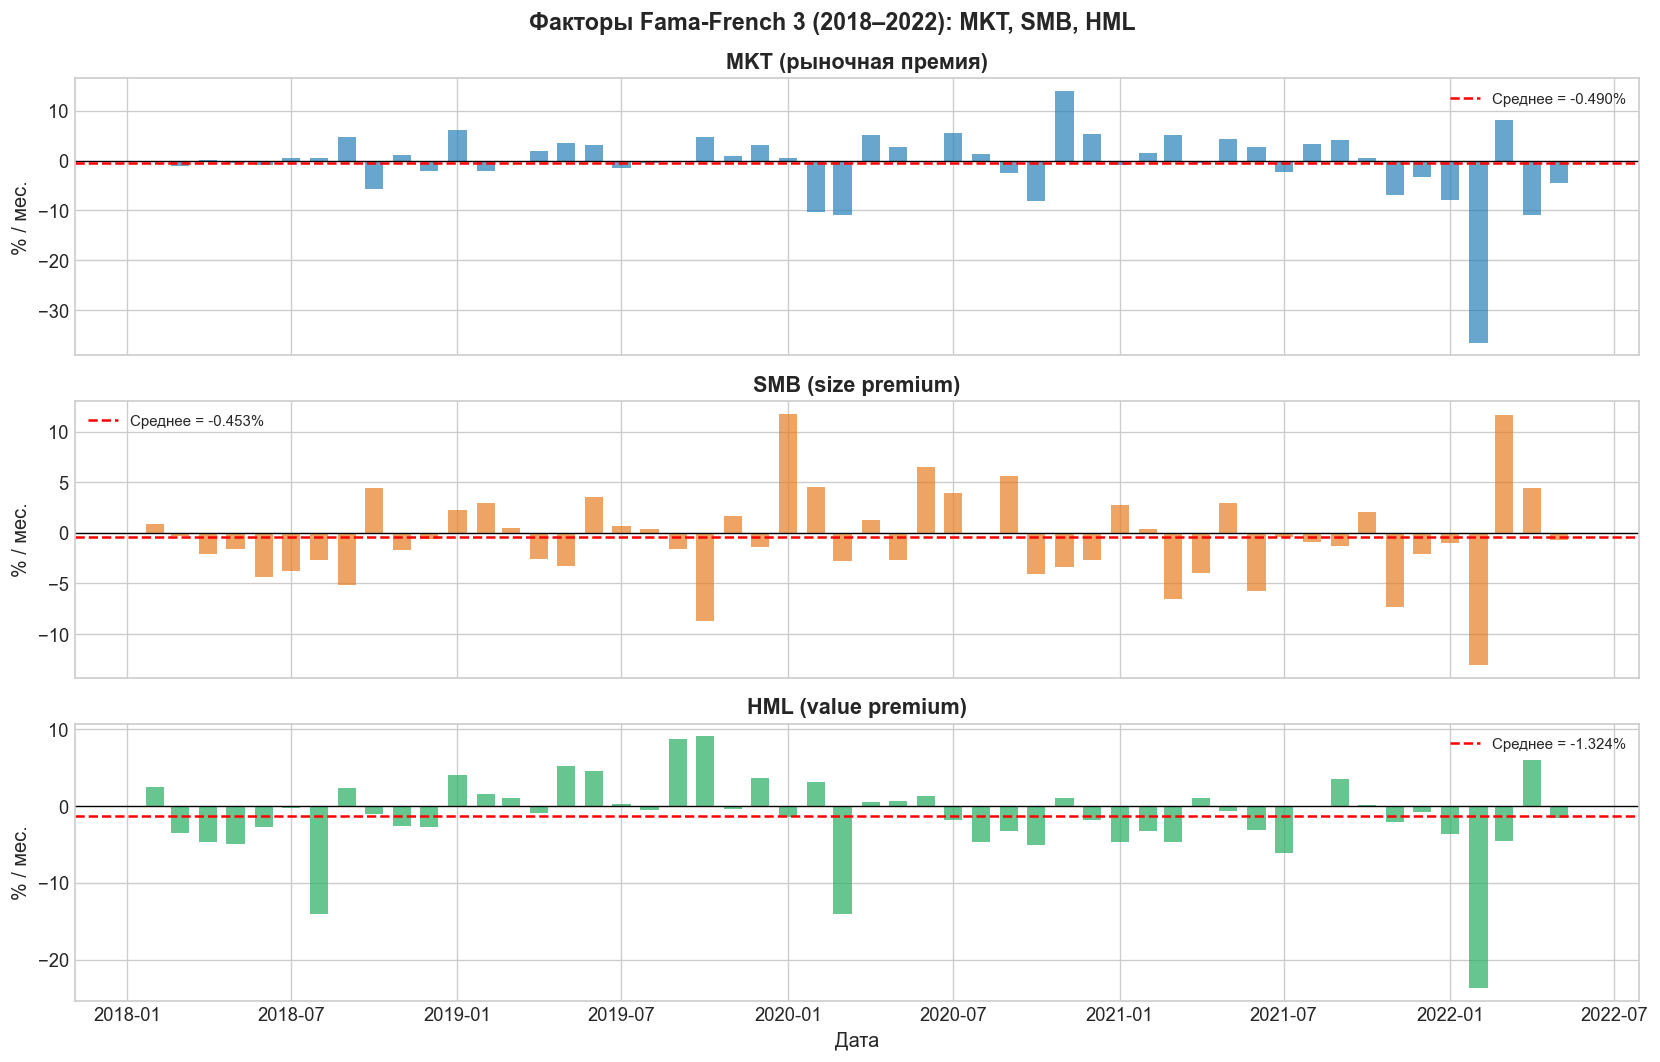

Сохранено: ff3_factors.png


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# 17. SMB + HML FACTOR CONSTRUCTION (2×3 sort, Fama & French 1993)
# ─────────────────────────────────────────────────────────────────────────────
import time

# Step 1: Fetch sharesOutstanding and priceToBook from yfinance
print('Загружаем fundamental данные (sharesOutstanding, priceToBook)...')
tickers_me = [n + '.ME' for n in names]   # восстанавливаем .ME суффикс

fund_data = {}
for ticker_me, name in zip(tickers_me, names):
    try:
        info = yf.Ticker(ticker_me).info
        shares = info.get('sharesOutstanding', None)
        pb     = info.get('priceToBook', None)
        fund_data[name] = {'shares': shares, 'priceToBook': pb}
    except Exception as e:
        fund_data[name] = {'shares': None, 'priceToBook': None}
    time.sleep(0.1)   # avoid rate-limiting

fund_df = pd.DataFrame(fund_data).T
print('\nFundamental data:')
print(fund_df.to_string())

# Step 2: Market cap time-series = shares_outstanding × monthly price
# Use prices from close (already loaded), convert .ME → clean names
prices_clean = close.copy()
prices_clean.columns = [c.replace('.ME', '') for c in prices_clean.columns]
# Keep only our 26 stocks
prices_clean = prices_clean[[n for n in names if n in prices_clean.columns]]

mcap = pd.DataFrame(index=prices_clean.index, columns=names, dtype=float)
for name in names:
    shares = fund_data[name]['shares']
    if shares is not None and name in prices_clean.columns:
        mcap[name] = prices_clean[name] * shares

print(f'\nMarket cap available for {mcap.notna().any().sum()}/{len(names)} stocks')

# Step 3: Annual rebalancing — determine B/M groups from P/B proxy
# P/B proxy: current value from yfinance (2026); treated as stable for classification
pb_values = {}
for name in names:
    pb = fund_data[name]['priceToBook']
    pb_values[name] = pb

# Classify B/M: anomalous P/B (< 0 or > 10 or None) → Neutral
# High B/M (value) = low P/B (bottom 30%)
# Low B/M (growth) = high P/B (top 30%)
valid_pb = {n: pb for n, pb in pb_values.items() if pb is not None and 0 < pb <= 10}
invalid_pb = {n for n in names if n not in valid_pb}

pb_series = pd.Series(valid_pb).sort_values()
n_valid   = len(pb_series)
lo_cut    = pb_series.quantile(0.30)   # below → High B/M (value)
hi_cut    = pb_series.quantile(0.70)   # above → Low B/M (growth)

bm_group = {}
for name in names:
    if name in invalid_pb:
        bm_group[name] = 'N'  # Neutral
    else:
        pb = pb_values[name]
        if pb <= lo_cut:
            bm_group[name] = 'H'   # High B/M = value
        elif pb >= hi_cut:
            bm_group[name] = 'L'   # Low B/M = growth
        else:
            bm_group[name] = 'N'   # Neutral

print('\nB/M groups (H=value, N=neutral, L=growth):')
bm_df = pd.DataFrame({'P/B': pb_values, 'B/M group': bm_group}).T
print(bm_df.to_string())

# Step 4: Compute 6 portfolio returns with annual size rebalancing
# Rebalancing years: at end of June each year (portfolio effective July–June)
# Since we have limited data (2018-02 – 2022-05), we use one or few rebalancing points

portfolio_rets = {p: [] for p in ['SL','SM','SH','BL','BM','BH']}
portfolio_dates = []

# Determine size groups per rebalancing year
def get_size_groups(mcap_row, names_list):
    """Returns dict name -> 'S' or 'B' based on median market cap split"""
    valid = {n: mcap_row[n] for n in names_list if pd.notna(mcap_row.get(n, np.nan))}
    if len(valid) < 4:
        return {}
    median_mc = np.median(list(valid.values()))
    return {n: ('B' if v >= median_mc else 'S') for n, v in valid.items()}

# Assign portfolio: combine size (S/B) with B/M (H/N/L)
def assign_portfolio(size, bm):
    return size + bm  # e.g. 'SH', 'BL', etc.

# Iterate over each month in common_idx
# Rebalancing: use June market cap of each year to determine Big/Small for next 12 months
current_size_groups = {}
current_rebal_year = None

smb_series = []
hml_series = []
factor_dates = []

for period in common_idx:
    month = period.month
    year  = period.year

    # Rebalance at end of June (use June market cap)
    if month == 6 or current_rebal_year is None:
        june_mcap = mcap.loc[period] if period in mcap.index else mcap.iloc[0]
        size_groups = get_size_groups(june_mcap, names)
        if size_groups:
            current_size_groups = size_groups
            current_rebal_year  = year

    if not current_size_groups:
        continue

    # Get returns for this month
    if period not in ER.index:
        continue
    er_t = ER.loc[period]

    # Build 6 portfolios
    port_members = {'SL':[], 'SM':[], 'SH':[], 'BL':[], 'BM':[], 'BH':[]}
    for name in names:
        if name not in current_size_groups:
            continue
        if pd.isna(er_t.get(name, np.nan)):
            continue
        sz  = current_size_groups[name]
        bm  = bm_group[name]
        key = sz + bm
        if key in port_members:
            port_members[key].append(er_t[name])

    # Equal-weighted portfolio returns
    port_ret = {}
    for key, rets in port_members.items():
        port_ret[key] = np.mean(rets) if rets else np.nan

    # SMB = (SL + SM + SH) / 3 - (BL + BM + BH) / 3
    smb_vals = [port_ret.get(k, np.nan) for k in ['SL','SM','SH']]
    big_vals  = [port_ret.get(k, np.nan) for k in ['BL','BM','BH']]
    smb_t = np.nanmean(smb_vals) - np.nanmean(big_vals) if not all(np.isnan(smb_vals)) else np.nan

    # HML = (SH + BH) / 2 - (SL + BL) / 2
    hml_t = (np.nanmean([port_ret.get('SH', np.nan), port_ret.get('BH', np.nan)]) -
             np.nanmean([port_ret.get('SL', np.nan), port_ret.get('BL', np.nan)]))

    smb_series.append(smb_t)
    hml_series.append(hml_t)
    factor_dates.append(period)

SMB = pd.Series(smb_series, index=pd.PeriodIndex(factor_dates, freq='M'), name='SMB')
HML = pd.Series(hml_series, index=pd.PeriodIndex(factor_dates, freq='M'), name='HML')

# Align all three factors on common index
ff3_idx = SMB.dropna().index.intersection(HML.dropna().index).intersection(MKT.index)
SMB_a   = SMB.loc[ff3_idx]
HML_a   = HML.loc[ff3_idx]
MKT_a   = MKT.loc[ff3_idx]

print(f'\nFF3 factors available: {len(ff3_idx)} months ({ff3_idx[0]} – {ff3_idx[-1]})')
print('\n=== Factor Statistics (monthly, excess returns) ===')
factor_stats = pd.DataFrame({
    'Mean % (мес.)': [MKT_a.mean()*100, SMB_a.mean()*100, HML_a.mean()*100],
    'Std % (мес.)':  [MKT_a.std()*100,  SMB_a.std()*100,  HML_a.std()*100],
    'Sharpe (год)':  [MKT_a.mean()/MKT_a.std()*np.sqrt(12),
                      SMB_a.mean()/SMB_a.std()*np.sqrt(12),
                      HML_a.mean()/HML_a.std()*np.sqrt(12)],
    't-stat':        [MKT_a.mean()/(MKT_a.std()/np.sqrt(len(MKT_a))),
                      SMB_a.mean()/(SMB_a.std()/np.sqrt(len(SMB_a))),
                      HML_a.mean()/(HML_a.std()/np.sqrt(len(HML_a)))],
}, index=['MKT','SMB','HML']).round(4)
print(factor_stats.to_string())

print('\n=== Factor Correlations ===')
factors_panel = pd.DataFrame({'MKT': MKT_a, 'SMB': SMB_a, 'HML': HML_a})
print(factors_panel.corr().round(3).to_string())

# Plot factor time-series
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
ts_idx = ff3_idx.to_timestamp()
for ax, factor, col, label in zip(
    axes,
    [MKT_a, SMB_a, HML_a],
    ['#2980b9', '#e67e22', '#27ae60'],
    ['MKT (рыночная премия)', 'SMB (size premium)', 'HML (value premium)']
):
    ax.bar(ts_idx, factor*100, color=col, alpha=0.7, width=20)
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(factor.mean()*100, color='red', ls='--', lw=1.5,
               label=f'Среднее = {factor.mean()*100:.3f}%')
    ax.set_ylabel('% / мес.')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Дата')
fig.suptitle('Факторы Fama-French 3 (2018–2022): MKT, SMB, HML', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ff3_factors.png', dpi=120, bbox_inches='tight')
plt.show()
print('Сохранено: ff3_factors.png')

### 2.2 Time-Series FF3 Regression

Для каждой акции $i$ оцениваем:
$$r_{i,t} - r_{f,t} = \alpha_i + \beta_i \cdot \text{MKT}_t + s_i \cdot \text{SMB}_t + h_i \cdot \text{HML}_t + \varepsilon_{i,t}$$

Стандартные ошибки — **HAC (Newey-West, 3 lags)**.

=== FF3 Time-Series OLS (HAC SE, Newey-West 3 lags) ===
        Alpha % (мес.)    t(α)   Beta    t(β)  s (SMB)    t(s)  h (HML)    t(h)     R²  Adj. R²   N α sig
Ticker                                                                                                   
PLZL            1.5560  1.4200 0.0827  0.5500   0.7489  4.2900  -0.1686 -0.7000 0.1176   0.0624  52      
TRNFP          -1.2313 -1.6300 0.0984  0.6600  -0.6235 -2.0900   0.3505  1.8000 0.1915   0.1410  52      
HYDR            0.4360  0.5700 0.2289  0.9600   0.4218  1.8300   0.0721  0.4100 0.2195   0.1707  52      
CHMF            0.7520  0.8800 0.2809  1.6400  -0.4521 -1.4000  -0.2348 -0.6700 0.0900   0.0332  52      
GMKN            0.7781  0.9400 0.3613  3.4500  -0.0902 -0.4500   0.0084  0.0700 0.1684   0.1164  52      
NLMK            0.4310  0.5100 0.4348  4.4800  -0.0701 -0.2500  -0.3602 -1.5600 0.1259   0.0713  52      
IRAO           -0.0524 -0.0800 0.5262  4.5700   0.4821  2.1800   0.2104  1.1500 0.5081   0.4774 

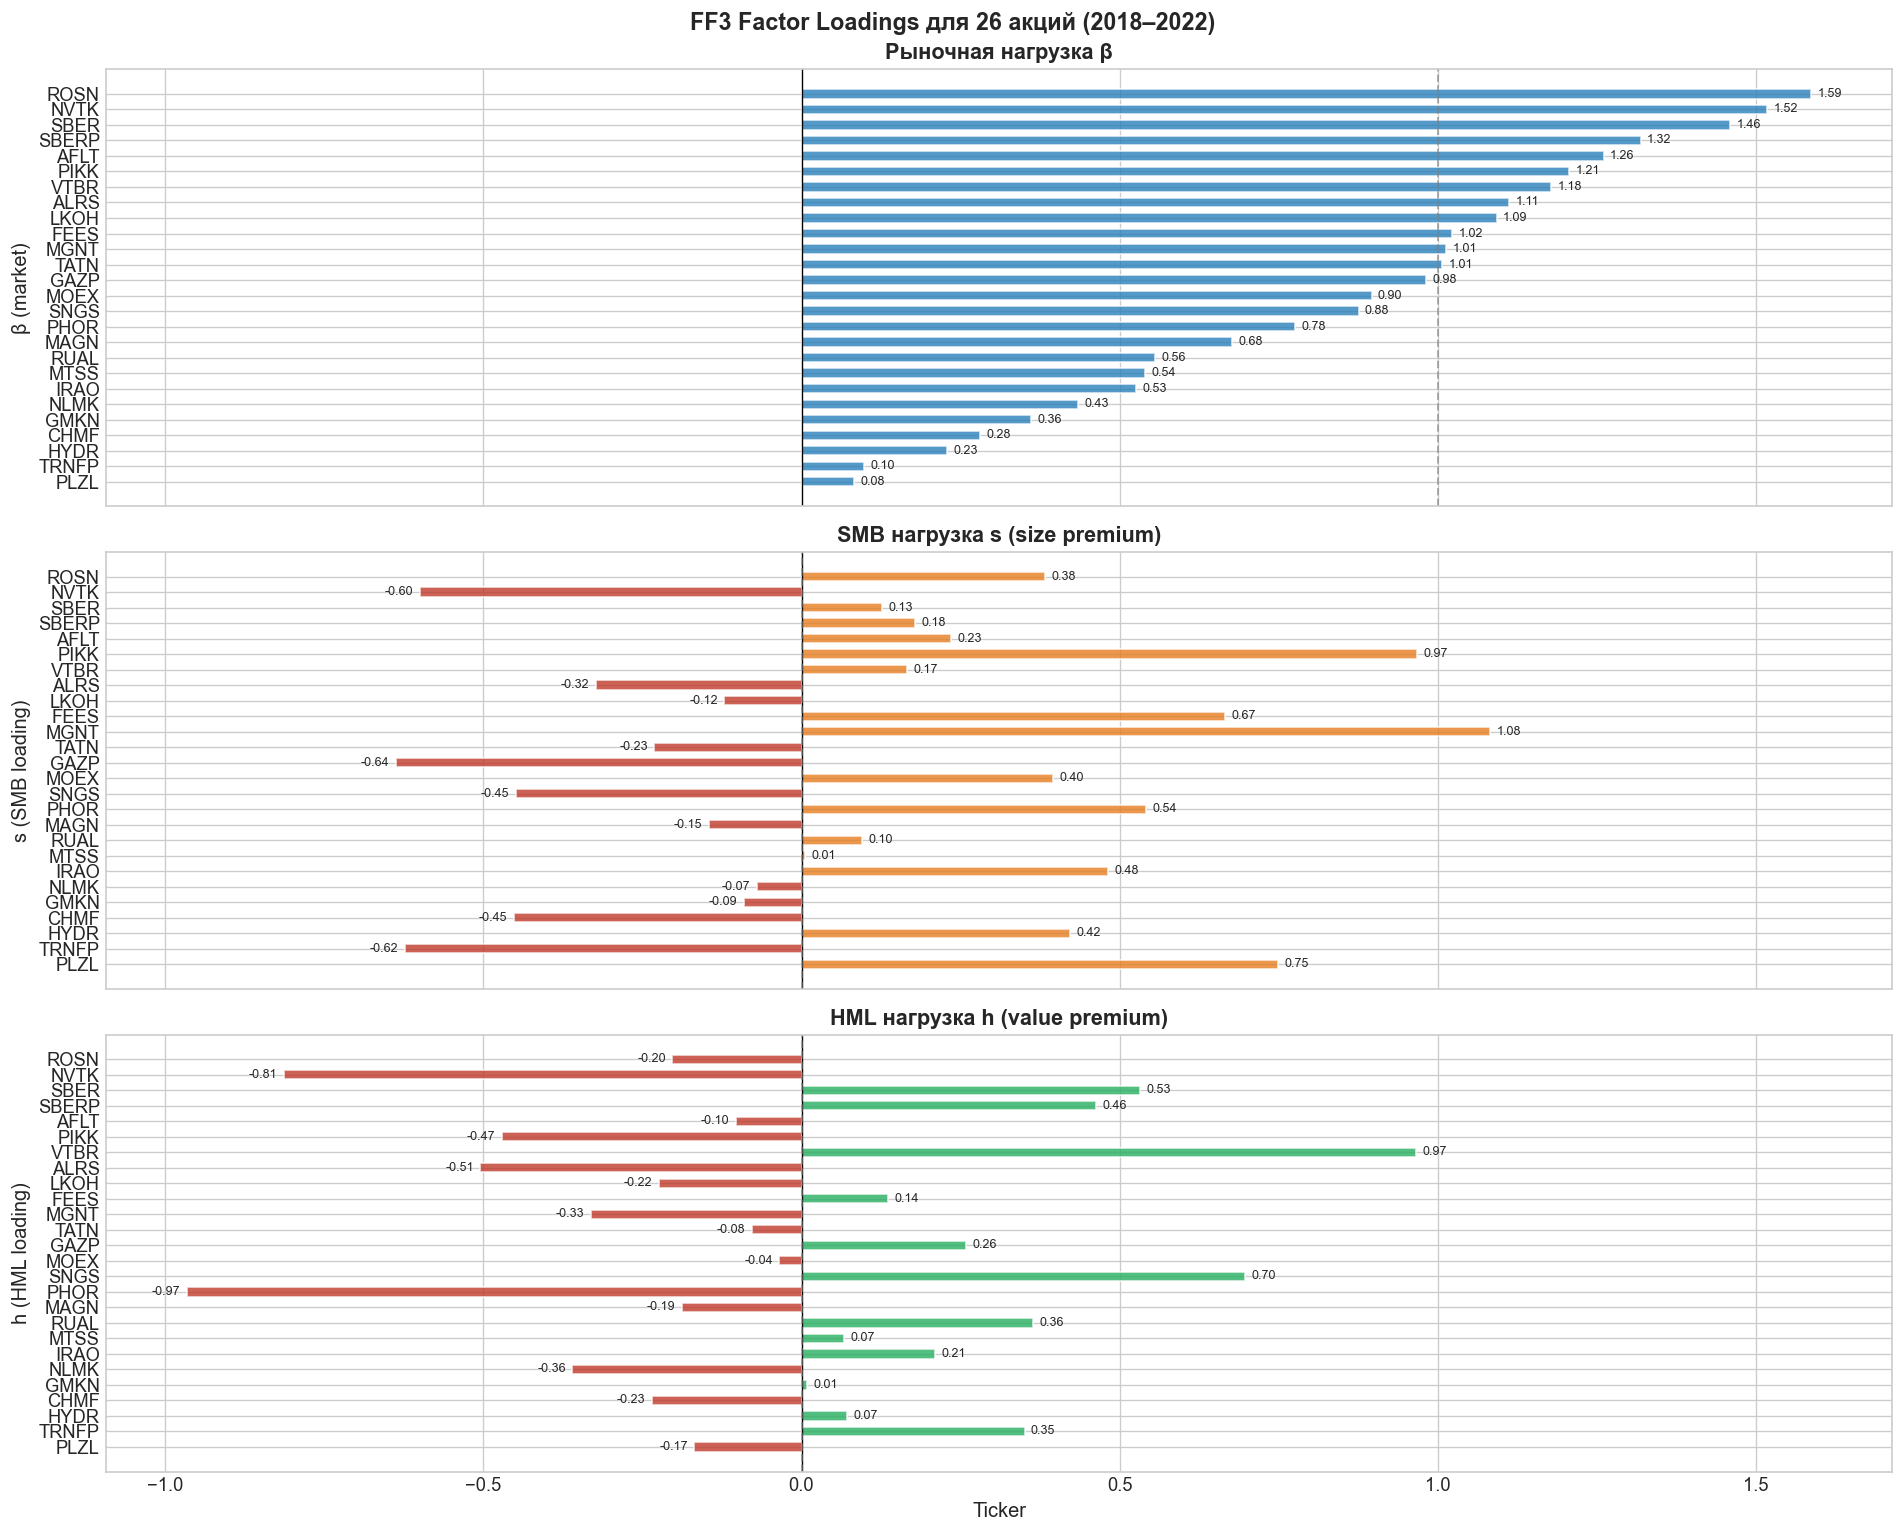

Сохранено: ff3_loadings.png


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# 18. TIME-SERIES FF3 OLS (HAC SE)
# ─────────────────────────────────────────────────────────────────────────────
ff3_results  = []
ff3_residuals = {}

# Align ER to FF3 index
ER_ff3 = ER.loc[ff3_idx]

for name in names:
    mask = ER_ff3[name].notna() & MKT_a.notna() & SMB_a.notna() & HML_a.notna()
    y = ER_ff3[name][mask].values
    X = sm.add_constant(
        pd.DataFrame({'MKT': MKT_a[mask], 'SMB': SMB_a[mask], 'HML': HML_a[mask]}).values
    )

    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})

    res_series = pd.Series(np.nan, index=ff3_idx)
    res_series[mask] = model.resid
    ff3_residuals[name] = res_series

    ff3_results.append({
        'Ticker':         name,
        'Alpha % (мес.)': round(model.params[0] * 100, 4),
        't(α)':           round(model.tvalues[0], 2),
        'Beta':           round(model.params[1], 4),
        't(β)':           round(model.tvalues[1], 2),
        's (SMB)':        round(model.params[2], 4),
        't(s)':           round(model.tvalues[2], 2),
        'h (HML)':        round(model.params[3], 4),
        't(h)':           round(model.tvalues[3], 2),
        'R²':             round(model.rsquared, 4),
        'Adj. R²':        round(model.rsquared_adj, 4),
        'N':              int(model.nobs),
        'α sig':          '*' if abs(model.tvalues[0]) > 1.96 else '',
    })

ff3_df = pd.DataFrame(ff3_results).set_index('Ticker').sort_values('Beta')

print('=== FF3 Time-Series OLS (HAC SE, Newey-West 3 lags) ===')
print(ff3_df.to_string())

n_sig_ff3 = (ff3_df['α sig'] == '*').sum()
print(f'\nЗначимых α FF3 (|t|>1.96): {n_sig_ff3}/{len(ff3_df)}')
print(f'Значимых α CAPM:           {(ts_df["α sig"]=="*").sum()}/{len(ts_df)}')
print(f'Средний R² FF3:  {ff3_df["R²"].mean():.3f}  vs CAPM: {ts_df["R²"].mean():.3f}')
print(f'Средний Adj.R² FF3: {ff3_df["Adj. R²"].mean():.3f}')

# ── Visualise factor loadings (3-panel bar chart)
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
order = ff3_df.index.tolist()

for ax, col, color, xlabel, title in zip(
    axes,
    ['Beta', 's (SMB)', 'h (HML)'],
    ['#2980b9', '#e67e22', '#27ae60'],
    ['β (market)', 's (SMB loading)', 'h (HML loading)'],
    ['Рыночная нагрузка β', 'SMB нагрузка s (size premium)', 'HML нагрузка h (value premium)']
):
    vals = ff3_df.loc[order, col]
    colors = [color if v >= 0 else '#c0392b' for v in vals]
    bars = ax.barh(order, vals, color=colors, alpha=0.8, edgecolor='white', height=0.6)
    ax.axvline(0, color='black', lw=0.8)
    # Mark significant
    ref = 1.0 if col == 'Beta' else 0.0
    ax.axvline(ref, color='gray', ls='--', lw=1.2, alpha=0.6)
    for bar, val in zip(bars, vals):
        ax.text(val + (0.01 if val >= 0 else -0.01),
                bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=7.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(xlabel)

axes[-1].set_xlabel('Ticker')
fig.suptitle('FF3 Factor Loadings для 26 акций (2018–2022)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ff3_loadings.png', dpi=120, bbox_inches='tight')
plt.show()
print('Сохранено: ff3_loadings.png')

### 2.3 Fama-MacBeth FF3 Two-Pass Regression

**Pass 1:** Полновыборочные нагрузки $\hat{\beta}_i$, $\hat{s}_i$, $\hat{h}_i$ из шага 2.2.

**Pass 2:** Для каждого месяца $t$ — кросс-секционная OLS:
$$r_{i,t} - r_{f,t} = \gamma_{0,t} + \gamma_{1,t}\hat{\beta}_i + \gamma_{2,t}\hat{s}_i + \gamma_{3,t}\hat{h}_i + \varepsilon_{i,t}$$

**FM оценки:** $\hat{\gamma}_k = \frac{1}{T}\sum_t \hat{\gamma}_{k,t}$,\;$\text{SE} = s(\gamma_{k,t})/\sqrt{T}$

**Вопрос:** оценивает ли российский рынок SMB и HML наряду с рыночным риском?

=== Fama-MacBeth FF3 Two-Pass Regression ===
Периодов: T = 52  |  Акций: N = 26

                 Estimate % (мес.) Std Error  t-stat p-value FF3 factor mean % Sig. 5%
γ₀ (intercept)              0.6120    0.5393  1.1300  0.2617            0.0000     Нет
γ₁ (β-premium)             -0.8901    1.1097 -0.8000  0.4262           -0.4904     Нет
γ₂ (SMB-premium)            0.0020    0.7105  0.0000  0.9978           -0.4529     Нет
γ₃ (HML-premium)           -1.7582    0.7878 -2.2300  0.0301           -1.3238      Да

--- Интерпретация ---
[○] γ₂ (SMB) = 0.0020%  незначимо (t=0.00): size premium не подтверждена
[!] γ₃ (HML) = -1.7582%  ЗНАЧИМО (t=-2.23): value premium существует


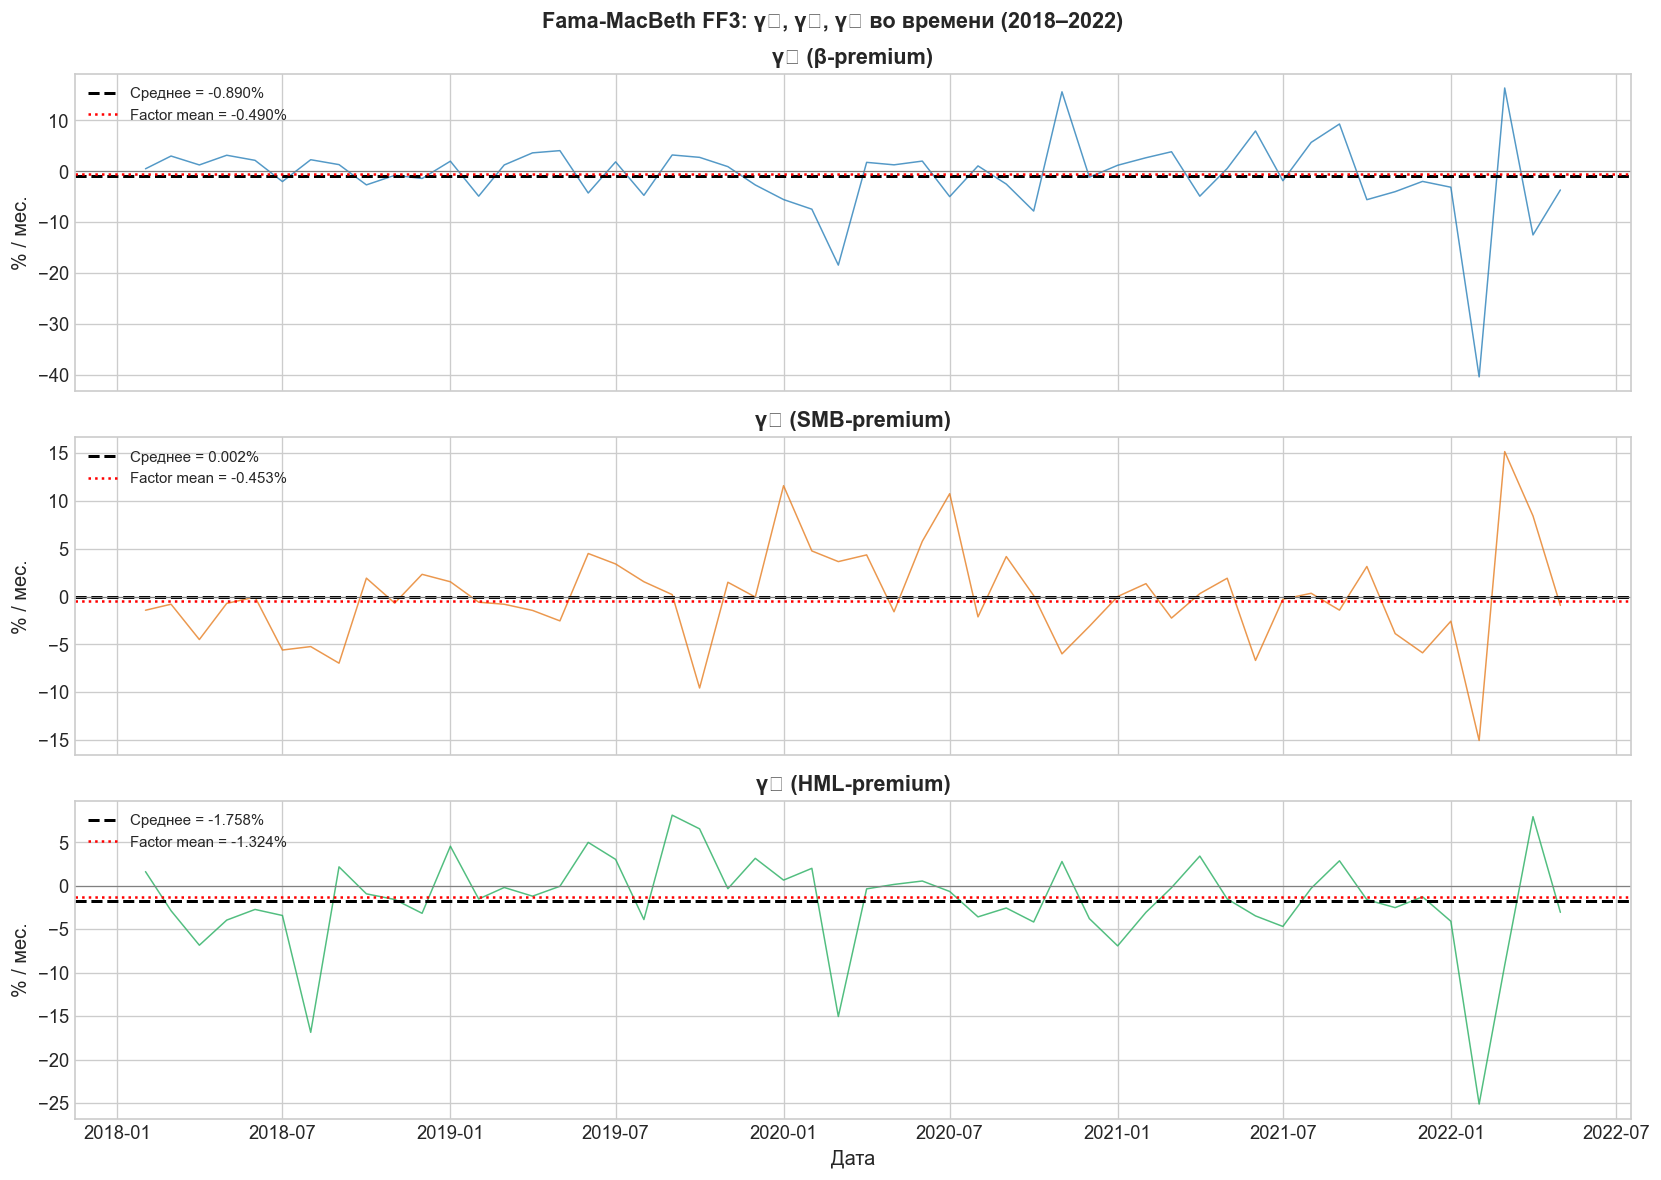

Сохранено: ff3_fm_gammas.png


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# 19. FAMA-MACBETH FF3 TWO-PASS
# ─────────────────────────────────────────────────────────────────────────────
fm_ff3_beta  = ff3_df['Beta']
fm_ff3_s     = ff3_df['s (SMB)']
fm_ff3_h     = ff3_df['h (HML)']

g0_ff3_t, g1_ff3_t, g2_ff3_t, g3_ff3_t = [], [], [], []
dates_ff3_fm = []

for t in ff3_idx:
    er_t = ER_ff3.loc[t].dropna()
    common_ff3 = er_t.index.intersection(fm_ff3_beta.index)

    if len(common_ff3) < 8:
        continue

    y_cs = er_t[common_ff3].values
    X_cs = sm.add_constant(
        np.column_stack([
            fm_ff3_beta[common_ff3].values,
            fm_ff3_s[common_ff3].values,
            fm_ff3_h[common_ff3].values,
        ])
    )

    try:
        res = sm.OLS(y_cs, X_cs).fit()
        g0_ff3_t.append(res.params[0])
        g1_ff3_t.append(res.params[1])
        g2_ff3_t.append(res.params[2])
        g3_ff3_t.append(res.params[3])
        dates_ff3_fm.append(t)
    except Exception:
        continue

g0_ff3_t = np.array(g0_ff3_t)
g1_ff3_t = np.array(g1_ff3_t)
g2_ff3_t = np.array(g2_ff3_t)
g3_ff3_t = np.array(g3_ff3_t)
T_ff3_fm = len(g0_ff3_t)

def fm_stats(gamma_arr, T):
    mean_ = gamma_arr.mean()
    se_   = gamma_arr.std(ddof=1) / np.sqrt(T)
    t_    = mean_ / se_
    p_    = 2 * (1 - stats.t.cdf(abs(t_), df=T-1))
    return mean_, se_, t_, p_

rows = {}
for label, arr, capm_pred in [
    ('γ₀ (intercept)', g0_ff3_t, 0.0),
    ('γ₁ (β-premium)',  g1_ff3_t, MKT_a.mean()),
    ('γ₂ (SMB-premium)', g2_ff3_t, SMB_a.mean()),
    ('γ₃ (HML-premium)', g3_ff3_t, HML_a.mean()),
]:
    m, se, t, p = fm_stats(arr, T_ff3_fm)
    rows[label] = {
        'Estimate % (мес.)': round(m*100, 4),
        'Std Error':          round(se*100, 4),
        't-stat':             round(t, 2),
        'p-value':            round(p, 4),
        'FF3 factor mean %':  round(capm_pred*100, 4),
        'Sig. 5%':            'Да' if abs(t) > 1.96 else 'Нет',
    }

fm_ff3_table = pd.DataFrame(rows).T
print('=== Fama-MacBeth FF3 Two-Pass Regression ===')
print(f'Периодов: T = {T_ff3_fm}  |  Акций: N = {len(common_ff3)}')
print()
print(fm_ff3_table.to_string())

print('\n--- Интерпретация ---')
g2_m, g2_se, g2_t, g2_p = fm_stats(g2_ff3_t, T_ff3_fm)
g3_m, g3_se, g3_t, g3_p = fm_stats(g3_ff3_t, T_ff3_fm)
g1_m, g1_se, g1_t, g1_p = fm_stats(g1_ff3_t, T_ff3_fm)

if abs(g2_t) > 1.96:
    print(f'[!] γ₂ (SMB) = {g2_m*100:.4f}%  ЗНАЧИМО (t={g2_t:.2f}): size premium существует')
else:
    print(f'[○] γ₂ (SMB) = {g2_m*100:.4f}%  незначимо (t={g2_t:.2f}): size premium не подтверждена')

if abs(g3_t) > 1.96:
    print(f'[!] γ₃ (HML) = {g3_m*100:.4f}%  ЗНАЧИМО (t={g3_t:.2f}): value premium существует')
else:
    print(f'[○] γ₃ (HML) = {g3_m*100:.4f}%  незначимо (t={g3_t:.2f}): value premium не подтверждена')

# ── Plot: γ₁, γ₂, γ₃ over time
ts_ff3_fm = pd.PeriodIndex(dates_ff3_fm, freq='M').to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, gdata, gmean, label, col, ref in zip(
    axes,
    [g1_ff3_t, g2_ff3_t, g3_ff3_t],
    [g1_m, g2_m, g3_m],
    ['γ₁ (β-premium)', 'γ₂ (SMB-premium)', 'γ₃ (HML-premium)'],
    ['#2980b9', '#e67e22', '#27ae60'],
    [MKT_a.mean(), SMB_a.mean(), HML_a.mean()]
):
    ax.plot(ts_ff3_fm, gdata * 100, color=col, lw=0.9, alpha=0.8)
    ax.axhline(gmean * 100,  color='black', ls='--', lw=1.8,
               label=f'Среднее = {gmean*100:.3f}%')
    ax.axhline(ref * 100, color='red', ls=':', lw=1.5,
               label=f'Factor mean = {ref*100:.3f}%')
    ax.axhline(0, color='gray', lw=0.7)
    ax.set_ylabel('% / мес.')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Дата')
fig.suptitle('Fama-MacBeth FF3: γ₁, γ₂, γ₃ во времени (2018–2022)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ff3_fm_gammas.png', dpi=120, bbox_inches='tight')
plt.show()
print('Сохранено: ff3_fm_gammas.png')

### 2.4 GRS Test для FF3

Совместная проверка: $H_0: \alpha_1^{FF3} = \alpha_2^{FF3} = \ldots = \alpha_N^{FF3} = 0$

$$F_{GRS}^{FF3} = \frac{T - N - K}{N} \cdot \frac{1}{1 + \hat{\mu}_f' \hat{\Omega}_f^{-1} \hat{\mu}_f} \cdot \hat{\alpha}'^{FF3} \hat{\Sigma}_{FF3}^{-1} \hat{\alpha}^{FF3}$$

где $K=3$ (число факторов). Сравниваем с GRS CAPM — снизилась ли совместная аномальность альф?

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# 20. GRS TEST FOR FF3
# ─────────────────────────────────────────────────────────────────────────────
ff3_resid_df = pd.DataFrame(ff3_residuals)[names].dropna()
T_ff3_grs = len(ff3_resid_df)
N_ff3_grs = len(names)
K_ff3     = 3   # number of factors (MKT, SMB, HML)

alpha_ff3_vec = ff3_df.loc[names, 'Alpha % (мес.)'].values / 100
Sigma_ff3     = ff3_resid_df.cov().values

# For FF3 GRS: mu_f = mean vector of [MKT, SMB, HML], Omega_f = cov matrix of factors
factors_panel_a = pd.DataFrame({'MKT': MKT_a, 'SMB': SMB_a, 'HML': HML_a}).loc[ff3_resid_df.index]
mu_f    = factors_panel_a.mean().values
Omega_f = factors_panel_a.cov().values

try:
    Omega_f_inv   = np.linalg.inv(Omega_f)
    Sigma_ff3_inv = np.linalg.inv(Sigma_ff3)

    sh2_f         = mu_f @ Omega_f_inv @ mu_f   # generalized Sharpe² of factors
    quad_ff3      = alpha_ff3_vec @ Sigma_ff3_inv @ alpha_ff3_vec

    ff3_grs_stat  = ((T_ff3_grs - N_ff3_grs - K_ff3) / N_ff3_grs) * (1 / (1 + sh2_f)) * quad_ff3
    df1_ff3       = N_ff3_grs
    df2_ff3       = T_ff3_grs - N_ff3_grs - K_ff3
    ff3_grs_pval  = 1 - stats.f.cdf(ff3_grs_stat, df1_ff3, df2_ff3)

    print('=== GRS Test — FF3 (Gibbons, Ross, Shanken 1989) ===')
    print(f'T = {T_ff3_grs},  N = {N_ff3_grs},  K = {K_ff3}')
    print(f'Generalized Sharpe² of factors: {sh2_f:.4f}')
    print(f'FF3 GRS statistic: {ff3_grs_stat:.4f}')
    print(f'FF3 GRS p-value:   {ff3_grs_pval:.4f}')

    if ff3_grs_pval < 0.01:
        print('[!!] H₀ ОТВЕРГАЕТСЯ при 1%: FF3 не описывает кросс-секцию доходностей')
    elif ff3_grs_pval < 0.05:
        print('[!]  H₀ ОТВЕРГАЕТСЯ при 5%: FF3 не описывает кросс-секцию доходностей')
    elif ff3_grs_pval < 0.10:
        print('[~]  H₀ отвергается при 10%')
    else:
        print('[✓]  H₀ НЕ отвергается: FF3 не противоречит данным')

    print()
    print('=== Сравнение CAPM vs FF3 (GRS) ===')
    print(f'CAPM: GRS = {grs_stat:.4f}  p = {grs_pval:.4f}')
    print(f'FF3:  GRS = {ff3_grs_stat:.4f}  p = {ff3_grs_pval:.4f}')
    print()

    # Mean absolute alpha comparison
    capm_maa = ts_df.loc[names, 'Alpha % (мес.)'].abs().mean()
    ff3_maa  = ff3_df.loc[names, 'Alpha % (мес.)'].abs().mean()
    print(f'Mean |alpha| CAPM: {capm_maa:.4f}%')
    print(f'Mean |alpha| FF3:  {ff3_maa:.4f}%')
    print(f'Reduction:         {((capm_maa - ff3_maa)/capm_maa)*100:.1f}%')

    if ff3_grs_stat < grs_stat:
        print('[+] FF3 улучшает модель: GRS статистика снизилась')
    else:
        print('[-] GRS FF3 выше CAPM — модель не улучшилась по этому критерию')

except np.linalg.LinAlgError as e:
    print(f'GRS FF3: матрица вырождена ({e})')
    ff3_grs_stat, ff3_grs_pval = np.nan, np.nan

=== GRS Test — FF3 (Gibbons, Ross, Shanken 1989) ===
T = 48,  N = 26,  K = 3
Generalized Sharpe² of factors: 0.0687
FF3 GRS statistic: 2.0074
FF3 GRS p-value:   0.0607
[~]  H₀ отвергается при 10%

=== Сравнение CAPM vs FF3 (GRS) ===
CAPM: GRS = 2.3816  p = 0.0231
FF3:  GRS = 2.0074  p = 0.0607

Mean |alpha| CAPM: 0.8801%
Mean |alpha| FF3:  0.7005%
Reduction:         20.4%
[+] FF3 улучшает модель: GRS статистика снизилась


### 2.5 Сравнительный дашборд: CAPM vs FF3

Четыре панели:
- **Верхний ряд:** α каждой акции по двум моделям + снижение |α|
- **Нижний ряд:** R² по акциям + сводная таблица GRS

**Гипотеза:** FF3 должна снизить аномальные альфы и улучшить R².

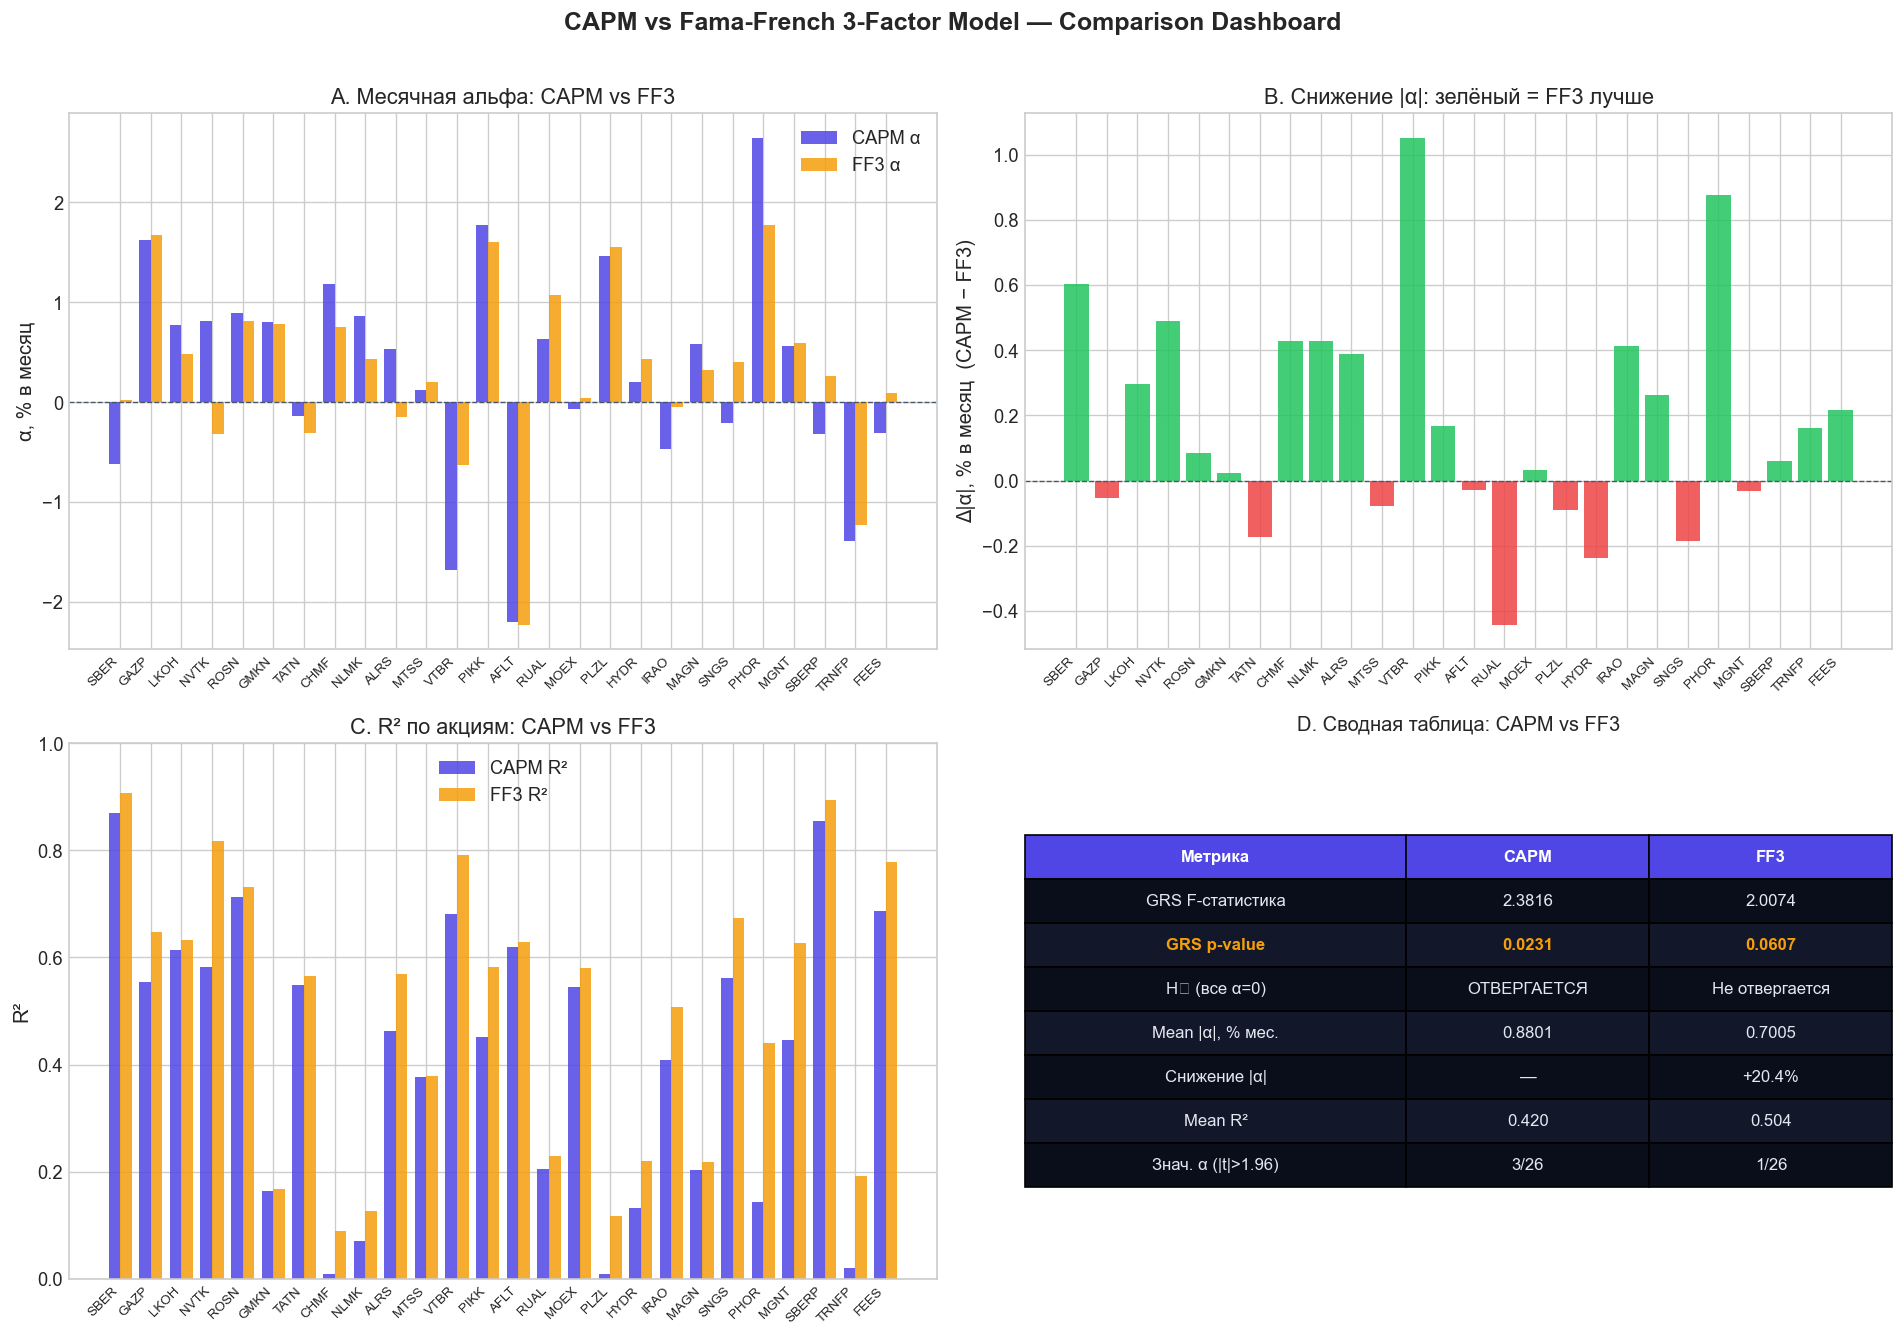


Сохранено: capm_vs_ff3.png
Снижение Mean|α|: 0.8801% → 0.7005%  (+20.4%)
Рост Mean R²:     0.420 → 0.504
Знач. α:          3 (CAPM) → 1 (FF3) из 26


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# 21. CAPM vs FF3 COMPARISON DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────
common_names = [n for n in names if n in ff3_df.index and n in ts_df.index]
tickers_short = [n.replace('.ME', '') for n in common_names]

capm_alpha = ts_df.loc[common_names, 'Alpha % (мес.)'].values
ff3_alpha  = ff3_df.loc[common_names, 'Alpha % (мес.)'].values
capm_r2    = ts_df.loc[common_names, 'R²'].values
ff3_r2     = ff3_df.loc[common_names, 'R²'].values
delta_r2   = ff3_r2 - capm_r2
abs_alpha_capm = np.abs(capm_alpha)
abs_alpha_ff3  = np.abs(ff3_alpha)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('CAPM vs Fama-French 3-Factor Model — Comparison Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

x = np.arange(len(common_names))
w = 0.38

# ── Panel A: Monthly alpha (CAPM vs FF3) ──────────────────────────────────
ax = axes[0, 0]
bars_capm = ax.bar(x - w/2, capm_alpha, width=w, label='CAPM α', color='#4f46e5', alpha=0.85)
bars_ff3  = ax.bar(x + w/2, ff3_alpha,  width=w, label='FF3 α',  color='#f59e0b', alpha=0.85)
ax.axhline(0, color='#475569', lw=0.8, ls='--')
ax.set_xticks(x); ax.set_xticklabels(tickers_short, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('α, % в месяц')
ax.set_title('A. Месячная альфа: CAPM vs FF3')
ax.legend(framealpha=0.9)

# ── Panel B: |alpha| reduction per stock ──────────────────────────────────
ax = axes[0, 1]
reduction = abs_alpha_capm - abs_alpha_ff3   # positive = FF3 reduced alpha
colors_b = ['#22c55e' if r >= 0 else '#ef4444' for r in reduction]
ax.bar(x, reduction, color=colors_b, alpha=0.85)
ax.axhline(0, color='#475569', lw=0.8, ls='--')
ax.set_xticks(x); ax.set_xticklabels(tickers_short, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Δ|α|, % в месяц  (CAPM − FF3)')
ax.set_title('B. Снижение |α|: зелёный = FF3 лучше')

# ── Panel C: R² comparison ────────────────────────────────────────────────
ax = axes[1, 0]
ax.bar(x - w/2, capm_r2, width=w, label='CAPM R²', color='#4f46e5', alpha=0.85)
ax.bar(x + w/2, ff3_r2,  width=w, label='FF3 R²',  color='#f59e0b', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(tickers_short, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('R²')
ax.set_title('C. R² по акциям: CAPM vs FF3')
ax.legend(framealpha=0.9)
ax.set_ylim(0, 1)

# ── Panel D: Summary table (GRS + mean stats) ─────────────────────────────
ax = axes[1, 1]
ax.axis('off')

capm_maa = abs_alpha_capm.mean()
ff3_maa  = abs_alpha_ff3.mean()
pct_red  = (capm_maa - ff3_maa) / capm_maa * 100

capm_r2_avg = capm_r2.mean()
ff3_r2_avg  = ff3_r2.mean()

n_sig_capm = (ts_df.loc[common_names, 'α sig'] == '*').sum()
ff3_tsig   = ff3_df.loc[common_names, 't(α)'].abs()
n_sig_ff3  = (ff3_tsig > 1.96).sum()

table_data = [
    ['Метрика',                'CAPM',              'FF3'],
    ['GRS F-статистика',       f'{grs_stat:.4f}',   f'{ff3_grs_stat:.4f}'],
    ['GRS p-value',            f'{grs_pval:.4f}',   f'{ff3_grs_pval:.4f}'],
    ['H₀ (все α=0)',           'ОТВЕРГАЕТСЯ' if grs_pval < 0.05 else 'Не отвергается',
                                'ОТВЕРГАЕТСЯ' if ff3_grs_pval < 0.05 else 'Не отвергается'],
    ['Mean |α|, % мес.',       f'{capm_maa:.4f}',   f'{ff3_maa:.4f}'],
    ['Снижение |α|',           '—',                 f'{pct_red:+.1f}%'],
    ['Mean R²',                f'{capm_r2_avg:.3f}', f'{ff3_r2_avg:.3f}'],
    ['Знач. α (|t|>1.96)',     f'{n_sig_capm}/{len(common_names)}',
                                f'{n_sig_ff3}/{len(common_names)}'],
]

col_widths = [0.44, 0.28, 0.28]
col_colors = [['#1e2340']*3] + [['#0a0d1a', '#1a2035', '#162030']]*len(table_data[1:])
header_colors = ['#2d3561', '#2d3561', '#2d3561']

tbl = ax.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc='center', loc='center',
    colWidths=col_widths,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.9)

# Style header
for j in range(3):
    tbl[(0, j)].set_facecolor('#4f46e5')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
# Style rows
for i in range(1, len(table_data)):
    for j in range(3):
        tbl[(i, j)].set_facecolor('#12172a' if i % 2 == 0 else '#0a0d1a')
        tbl[(i, j)].set_text_props(color='#e2e8f0')
# Highlight GRS p-value row
for j in range(3):
    tbl[(2, j)].set_text_props(color='#f59e0b', fontweight='bold')

ax.set_title('D. Сводная таблица: CAPM vs FF3', fontsize=12, pad=8)

plt.tight_layout()
plt.savefig('capm_vs_ff3.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nСохранено: capm_vs_ff3.png')
print(f'Снижение Mean|α|: {capm_maa:.4f}% → {ff3_maa:.4f}%  ({pct_red:+.1f}%)')
print(f'Рост Mean R²:     {capm_r2_avg:.3f} → {ff3_r2_avg:.3f}')
print(f'Знач. α:          {n_sig_capm} (CAPM) → {n_sig_ff3} (FF3) из {len(common_names)}')
